# Notebook 3 -- Multidimensional Deep Queue-Reactive (MDQR) Model

**Paper Reference:** *Deep Learning Meets Queue-Reactive: A Framework for Realistic Limit Order Book Simulation* (Bodor & Carlier, 2025)

**Objective:** While previous iterations of the Queue-Reactive framework model each queue independently, this notebook implements the Multidimensional Deep Queue-Reactive (MDQR) model. The MDQR framework conceptualizes the entire Limit Order Book (LOB) as a single, interdependent multidimensional system. The core methodological advancements include:

1. **Joint Intensity Modeling:** A unified neural architecture outputs 30 distinct event intensities simultaneously (representing Limit, Cancel, and Market orders across 10 spatial queues), facilitating the endogenous capture of cross-level and cross-side microstructural dependencies.
2. **Conditional Order-Size Distribution (SizeNet):** A secondary, specialized network explicitly models the distribution of order sizes conditional upon the macroscopic LOB state, the specific event type, and the spatial price level.
3. **Continuous-Time Simulation:** The integration of calibrated intensities and conditionally sampled order sizes into a Gillespie-type algorithm to generate synthetic, high-fidelity LOB trajectories.

### Key Methodological Shifts from the DQR Framework

| Architectural Property | Independent DQR (Notebook 2) | Joint MDQR (Notebook 3) |
|-------------------------|------------------------------|---------------------------|
| **Network Topology** | 10 independent networks | 1 shared joint network |
| **State Vector Dimension** | Localized to a single queue | Comprehensive 39-dimensional global state |
| **Output Dimension** | 3 intensities per network | 30 simultaneous intensities |
| **Activation Function** | ReLU | Softplus (ensures smooth, strictly positive gradients) |
| **Inter-Event Time** | Localized per-level | Global chronological inter-arrival |
| **Order-Size Mechanics** | Assumed unitary or static | Dynamic discrete classes via SizeNet |
| **Early Stopping Patience**| 10 epochs | 30 epochs (adapted for single-day equity noise) |

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
import gc
import os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
from scipy.stats import gamma as gamma_dist

from lobster import (load_lobster_data, compute_aes_by_level,
                     normalize_by_aes, make_descriptive_table)

# ── HARDWARE DETECTION (CUDA / MPS / CPU) ─────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using device: CUDA  ({torch.cuda.get_device_name(0)})")
    props = torch.cuda.get_device_properties(0)
    print(f"  VRAM: {props.total_memory/1024**3:.1f} GB | CUDA {props.major}.{props.minor}")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using device: Apple Silicon (MPS)")
    print("  Hardware acceleration enabled for Mac architectures.")
else:
    device = torch.device('cpu')
    print("Using device: CPU")
    print("  NOTE: Training will be slow on CPU; reduce EPOCHS if needed.")

# ── PLOTTING & REPRODUCIBILITY CONFIGURATION ──────────────────────────────────
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

np.random.seed(42)
torch.manual_seed(42)

Using device: CUDA  (NVIDIA GeForce GTX 1650 with Max-Q Design)
  VRAM: 4.0 GB | CUDA 7.5


---
## 1. Data Loading and Preprocessing

We use the same INTC LOBSTER dataset and preprocessing pipeline as Notebook 2:

1. **Reference price** $p_{\text{ref}}(t)$: disambiguates half-tick price levels when the spread is even (Section 2.1 of the paper).
2. **QR-grid regridding**: maps raw LOBSTER price levels to the $\pm 1, \ldots, \pm K$ grid centred on $p_{\text{ref}}$.
3. **AES normalisation**: $\tilde{q}_i \leftarrow \lceil q_i / \text{AES}_i \rceil$ transforms queue sizes into small integers (≈1–10), making gradient magnitudes stable across levels.

The shared-network design of MDQR requires that all $2K$ queue sizes are on a **consistent scale** — impossible without AES normalisation, since level-1 queues are typically an order of magnitude larger than level-5 queues.

In [39]:
# ── 1. Configuration & Variables ──────────────────────────────────────────────
PRIMARY = "INTC"
START_DATE = "2013-09-30"
END_DATE = "2013-10-30"
LEVELS = 5
K = 5
MARKET_OPEN_S  = 34200   # 09:30 in seconds since midnight
MARKET_CLOSE_S = 57600   # 16:00

EVENT_TO_IDX = {'L': 0, 'C': 1, 'M': 2}
IDX_TO_EVENT = {0: 'L', 1: 'C', 2: 'M'}

# Dynamic path to handle the new 1-month folder
DATA_DIR = Path("data2")
stock_folder = DATA_DIR / f"{PRIMARY}_{START_DATE}_{END_DATE}_{LEVELS}"

# Get all files sorted chronologically
msg_files = sorted(stock_folder.glob("*_message_5.csv"))
ob_files  = sorted(stock_folder.glob("*_orderbook_5.csv"))

if not msg_files:
    raise FileNotFoundError(f"No files found in {stock_folder}. Check your paths.")

print(f"Found {len(msg_files)} trading days. Starting memory-optimized processing...")

all_processed_dfs = []
daily_aes_list = []
tick_size = None

# ── 2. Memory-Optimized Daily Processing ──────────────────────────────────────
for msg_path, ob_path in zip(msg_files, ob_files):
    current_date = msg_path.name.split('_')[1]
    print(f"  -> Processing {current_date} ...")

    # Load data using your lobster.py function
    msg, ob, qr, df = load_lobster_data(
        str(msg_path), str(ob_path),
        levels=LEVELS, K=K, market_open_seconds=MARKET_OPEN_S
    )
    
    if tick_size is None:
        tick_size = int(qr['tick_size'].iloc[0])

    df = df.sort_values('time').reset_index(drop=True)

    # --- A. Rolling Trade Imbalances (TI) ---
    time_idx = pd.to_timedelta(df['time'], unit='s')
    df_temp = pd.DataFrame(index=time_idx)
    df_temp['vol_buy']  = np.where((df['type'] == 'M') & (df['lvl'] > 0), df['size'], 0.0)
    df_temp['vol_sell'] = np.where((df['type'] == 'M') & (df['lvl'] < 0), df['size'], 0.0)

    for tau, name in [(20, '20s'), (60, '1min'), (300, '5min'), (900, '15min')]:
        roll_buy  = df_temp['vol_buy'].rolling(f'{tau}s').sum().values
        roll_sell = df_temp['vol_sell'].rolling(f'{tau}s').sum().values
        total_vol = roll_buy + roll_sell
        df[f'TI_{name}'] = np.where(total_vol > 0, (roll_buy - roll_sell) / total_vol, 0.0)

    # --- B. Intra-day event memory (last event per level) ---
    df['event_type_idx'] = df['type'].map({'L': 1, 'C': 2, 'M': 3}).fillna(0).astype(int)
    for lvl in range(1, K+1):
        ask_mask = (df['lvl'] == lvl)
        df[f'last_ask_{lvl}'] = (ask_mask * df['event_type_idx']).replace(0, np.nan).ffill().shift(1).fillna(0).astype(int)
        
        bid_mask = (df['lvl'] == -lvl)
        df[f'last_bid_{lvl}'] = (bid_mask * df['event_type_idx']).replace(0, np.nan).ffill().shift(1).fillna(0).astype(int)

    # --- C. Basic Temporal Features ---
    df['hour'] = ((df['time'] - MARKET_OPEN_S) // 3600).astype(int).clip(0, 6)
    df['event_id'] = df['type'].map(EVENT_TO_IDX).astype(int)
    
    # Identify the day (useful later for the global_last edge case)
    df['date'] = current_date

    # Compute AES for this specific day and store it
    daily_aes = compute_aes_by_level(df, K=K)
    daily_aes_list.append(daily_aes)
    
    # Store only the necessary dataframe
    all_processed_dfs.append(df)
    
    # CRITICAL: Free up memory immediately by deleting heavy raw files
    del msg, ob, qr, df_temp
    gc.collect()

# ── 3. Aggregation and Global Normalization ───────────────────────────────────
print("\nConcatenating the full month dataset (this may take a moment)...")
df_full = pd.concat(all_processed_dfs, ignore_index=True)

# Free up the list memory
del all_processed_dfs
gc.collect()

# Compute global AES (mean across all days)
global_aes = pd.concat(daily_aes_list, axis=1).mean(axis=1)

print("Normalizing queues and sizes using global AES...")
# Uses your normalize_by_aes from lobster.py
df_norm = normalize_by_aes(df_full, aes=global_aes, K=K)

# ── 4. Diagnostics ────────────────────────────────────────────────────────────
print("\nDescriptive statistics (cf. Table 1 of the paper, 1-month aggregate):")
# Uses your make_descriptive_table from lobster.py
print(make_descriptive_table(df_full, K=K))

print(f"\nTotal events (all levels, all days): {len(df_norm):,}")
print(f"Global AES by level:\n{global_aes.round(2)}")
print(f"Tick size: {tick_size}")

Found 23 trading days. Starting memory-optimized processing...
  -> Processing 2013-09-30 ...
  -> Processing 2013-10-01 ...
  -> Processing 2013-10-02 ...
  -> Processing 2013-10-03 ...
  -> Processing 2013-10-04 ...
  -> Processing 2013-10-07 ...
  -> Processing 2013-10-08 ...
  -> Processing 2013-10-09 ...
  -> Processing 2013-10-10 ...
  -> Processing 2013-10-11 ...
  -> Processing 2013-10-14 ...
  -> Processing 2013-10-15 ...
  -> Processing 2013-10-16 ...
  -> Processing 2013-10-17 ...
  -> Processing 2013-10-18 ...
  -> Processing 2013-10-21 ...
  -> Processing 2013-10-22 ...
  -> Processing 2013-10-23 ...
  -> Processing 2013-10-24 ...
  -> Processing 2013-10-25 ...
  -> Processing 2013-10-28 ...
  -> Processing 2013-10-29 ...
  -> Processing 2013-10-30 ...

Concatenating the full month dataset (this may take a moment)...
Normalizing queues and sizes using global AES...

Descriptive statistics (cf. Table 1 of the paper, 1-month aggregate):
       #L (×10^3)  #C (×10^3)  #M (×10

### 1.1 Global Inter-Event Time and the LOBSTER Batch-Arrival Artefact

A fundamental methodological shift from the independent Deep Queue-Reactive (DQR) model (Notebook 2) to the multidimensional MDQR framework is the utilization of a **global inter-event time**:

$$\Delta t_k = t_k - t_{k-1}$$

where $t_{k-1}$ is the timestamp of the immediately preceding event *anywhere within the limit order book* (Section 4.2 of Bodor & Carlier, 2025). This global temporal definition is strictly necessary to properly evaluate the joint survival term $e^{-\Lambda(\mathbf{x}_k)\,\Delta t_k}$, where $\Lambda = \sum_j \lambda_j$ represents the aggregate intensity of the entire LOB. While the temporal scaling is global, the model meticulously preserves spatial memory: the state vector $\mathbf{x}_k$ explicitly incorporates both the last event specific to each structural level $e_i(t_k)$ and the most recent global event $e(t_k)$ to capture complex auto-excitation micro-dynamics.

**The LOBSTER Batch-Arrival Artefact:**
High-frequency empirical datasets, particularly LOBSTER (NASDAQ), chronically register distinct events with identical microsecond timestamps ($\Delta t_k \approx 0$). These occurrences do not signify genuinely simultaneous Poisson arrivals, but rather reflect exchange-level batch-processing and message-packet artifacts. During such events, the global survival term $\Lambda \cdot \Delta t_k$ effectively collapses to zero. Consequently, the Negative Log-Likelihood (NLL) optimization degenerates into a pure cross-entropy objective focused exclusively on event-type classification, inherently failing to penalize arbitrary inflation of the underlying intensities.

**Dual-Treatment Temporal Strategy:**
To circumvent this microstructural anomaly while adhering to the global Markovian framework, two distinct temporal protocols are enforced:

1. **Training Phase Clipping:** The operational $\Delta t_k$ fed into the loss function is strictly clipped to the interval $[10^{-6}\,\text{s},\; 30\,\text{s}]$. The absolute $1\,\mu\text{s}$ lower bound averts mathematically undefined $\log(0)$ gradients without artificially inflating the survival penalty during batch arrivals. Consequently, the calibration of the baseline global intensity $\Lambda$ is structurally driven by the subset of events exhibiting genuine, statistically independent inter-arrival intervals.
2. **Evaluation Phase (Timing Metric):** To ensure rigorous and unbiased validation, the median relative timing error (Section 7) is computed **strictly on events exhibiting an unclipped original $\Delta t_k > 1\,\text{ms}$**. This exclusionary filtering ensures the evaluation metric aligns flawlessly with the theoretical independent Poisson assumption, isolating genuine market tempo from the noise of microsecond batch processing.

=== Empirical Analysis of Normalized Order Sizes ===
  - 99% of orders exhibit a normalized size <= 8
  - 99.9% of orders exhibit a normalized size <= 22
  - Maximum observed normalized size: 546


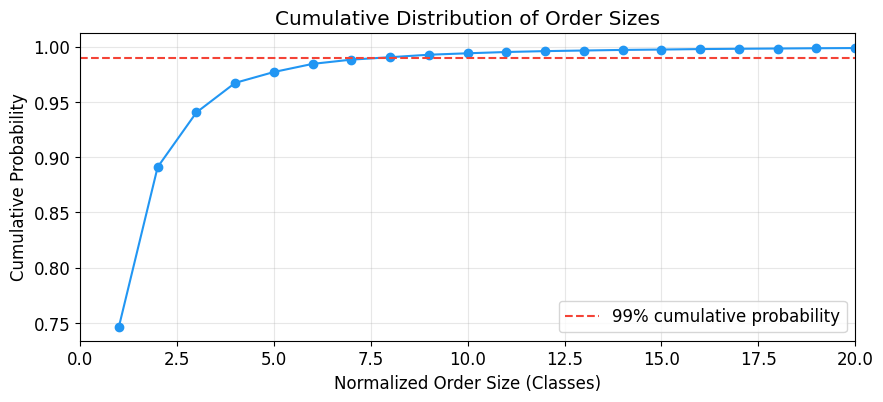


Conclusion: The original framework allocates 200 classes as 99.9% of Bund orders fall within this range.
For the current asset, 99.9% of the normalized orders fall strictly below 22.
Maintaining 200 classes would result in a highly sparse target vector, exacerbating gradient dilution
and destabilizing the softmax convergence over a single-day sample.
-> Action: The hyperparameter N_SIZE_CLS should be constrained to 22.


In [40]:
# ── SIZENET CLASS COUNT JUSTIFICATION ─────────────────────────────────────────
# This cell analyzes the empirical distribution of normalized order sizes
# to adapt the SizeNet architecture to the specific asset's characteristics.
# While the baseline MDQR model allocates 200 classes for the Bund futures 
# market (where 99.9% of normalized orders are < 200), equity data may exhibit 
# a significantly narrower categorical support.

empirical_sizes = df_norm['size'].dropna().values
pct_99 = np.percentile(empirical_sizes, 99)
pct_99_9 = np.percentile(empirical_sizes, 99.9)

print("=== Empirical Analysis of Normalized Order Sizes ===")
print(f"  - 99% of orders exhibit a normalized size <= {pct_99:.0f}")
print(f"  - 99.9% of orders exhibit a normalized size <= {pct_99_9:.0f}")
print(f"  - Maximum observed normalized size: {empirical_sizes.max():.0f}")

# Compute cumulative probabilities for visual diagnostic
val_counts = pd.Series(empirical_sizes).value_counts(normalize=True).sort_index().cumsum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_counts.index[:50], val_counts.values[:50], marker='o', linestyle='-', color='#2196F3')
ax.axhline(0.99, color='#F44336', linestyle='--', label='99% cumulative probability')
ax.set_xlim(0, max(20, pct_99 + 5))
ax.set_xlabel("Normalized Order Size (Classes)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Cumulative Distribution of Order Sizes")
ax.legend()
plt.show()

# Dynamic recommendation for N_SIZE_CLS
recommended_classes = int(pct_99_9)
print(f"\nConclusion: The original framework allocates 200 classes as 99.9% of Bund orders fall within this range.")
print(f"For the current asset, 99.9% of the normalized orders fall strictly below {recommended_classes}.")
print(f"Maintaining 200 classes would result in a highly sparse target vector, exacerbating gradient dilution")
print(f"and destabilizing the softmax convergence over a single-day sample.")
print(f"-> Action: The hyperparameter N_SIZE_CLS should be constrained to {max(10, recommended_classes)}.")

---
## 2. MDQR Mathematical Formulation (Section 4)

### 2.1 Event space and factored likelihood

Each event $e_k = (\eta_k, \ell_k, \Delta t_k, s_k, \mathbf{x}_k)$ is characterised by its type $\eta_k \in \{L, C, M\}$, spatial price level $\ell_k \in \{-K,\ldots,-1,1,\ldots,K\}$, **global inter-event time** $\Delta t_k$, normalized order size $s_k$, and the comprehensive state vector $\mathbf{x}_k$.

The joint likelihood of the event sequence mathematically factorises as (Eq. 3):

$$
\mathcal{L}(\theta \mid \mathcal{E}) =
\underbrace{\prod_{k=1}^{N} e^{-\Lambda(\mathbf{x}_k;\theta)\,\Delta t_k}\,
\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k;\theta)}_{\text{intensity component}} \times
\underbrace{\prod_{k=1}^{N} p(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)}_{\text{size component}}
$$

The intensity generating process and the order-size distribution are conditionally independent given the state vector and are optimised through separate neural architectures.

### 2.2 Intensity NLL (Eq. 4)

Applying the negative logarithm yields the empirical NLL objective:

$$
\mathcal{L}_\lambda(\theta)
= \frac{1}{N}\sum_{k=1}^{N}\Bigl[
  \underbrace{\Lambda(\mathbf{x}_k;\theta)\,\Delta t_k}_{\text{survival term}}
  -\underbrace{\log\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k;\theta)}_{\text{event likelihood}}
\Bigr]
$$

where $\Lambda = \sum_{j=1}^{30}\lambda_j$ is the aggregate event rate across all modeled spatial dimensions. The survival term imposes a structural penalty against overestimating the aggregate rate: for a given observation, the network must optimally concentrate its intensity on the correct $(\eta_k,\ell_k)$ combination while maintaining a global $\Lambda$ commensurate with the observed inter-arrival tempo $1/\Delta t_k$.

### 2.3 Order-size cross-entropy (Eq. 5)

$$
\mathcal{L}_s(\phi)
= -\frac{1}{N}\sum_{k=1}^{N}\sum_{c=1}^{C}
  y_{k,c}\,\log\hat{p}_c(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)
$$

where the $C$ discrete classes correspond to dynamic quantile bins designed to balance the heavily skewed empirical normalized size distribution.

### 2.4 Event index spatial encoding

To facilitate joint multidimensional output, each of the $3 \times 2K = 30$ output neurons is mapped to an exact spatial index:

$$j = \text{type\_idx} \times 2K + \text{side\_idx} \times K + (\ell - 1), \quad j \in \{0,\ldots,29\}$$

where type\_idx $\in \{0{=}L,\,1{=}C,\,2{=}M\}$, side\_idx $\in \{0{=}\text{ask},\,1{=}\text{bid}\}$.

## 3. Neural Network Architecture

The MDQR framework relies on a dual-network topology: the intensity model (`MDQRNet`) and the order-size model (`SizeNet`). Both networks utilize a feed-forward Multi-Layer Perceptron (MLP) architecture but differ in their input representations and output activations to serve their respective probabilistic objectives. 

Table 1 details the exact architectural specifications implemented in this environment, which expands upon the baseline model to capture deeper spatial memory.

**Table 1: Topological Specifications of the MDQR Framework**

| Component | MDQRNet (Intensity Model) | SizeNet (Order-Size Model) |
|-----------|---------------------------|----------------------------|
| **Input Dimension** | 39 | 41 |
| **Hidden Topology** | [256, 64] | [256, 64] |
| **Hidden Activation** | Tanh | Tanh |
| **Output Dimension** | 30 | $C$ (Dynamic discrete classes) |
| **Output Activation** | Softplus | Softmax (Temperature-scaled at inference) |
| **Batch Normalization** | None | None |

**Architectural Rationale:**

*   **Softplus vs. ReLU Activation:** While the original paper specifies a ReLU activation for the intensity output, this implementation utilizes the Softplus function, $f(x) = \ln(1 + e^x)$. Softplus provides a smooth, strictly positive approximation of ReLU, which prevents the "dying neuron" pathology during the calculation of the survival term $\Lambda \cdot \Delta t_k$ and ensures computational stability when taking the logarithm of the intensities for the Negative Log-Likelihood (NLL) objective.
*   **Omission of Batch Normalization:** The explicit exclusion of Batch Normalization layers is a deliberate architectural choice. Given the finite temporal horizon of the calibration data (a single trading day), the running statistics accumulated during training batches would significantly diverge from the true marginal statistics of the evaluation set, introducing systemic train-evaluation discrepancies.

In [41]:
# ── Event index helpers ──────────────────────────────────────────────────
def encode_event_j(t_type, lvl, K):
    type_idx = EVENT_TO_IDX.get(t_type, -1)
    if type_idx < 0 or lvl == 0:
        return -1
    side_idx  = 0 if lvl > 0 else 1
    level_idx = abs(lvl) - 1
    if level_idx >= K:
        return -1
    return type_idx * (2 * K) + side_idx * K + level_idx

def decode_event_j(j, K):
    type_idx  = j // (2 * K)
    rem       = j % (2 * K)
    side_idx  = rem // K
    level_idx = rem % K
    return type_idx, side_idx, level_idx

# ── MDQRNet (Intensity Model) ─────────────────────────────────────────────
class MDQRNet(nn.Module):
    def __init__(self, K=5, n_cont=15, n_hour=7, n_last_classes=4, n_global_classes=31, emb_dim=2, hidden=(256, 64)):
        super().__init__()
        self.K = K
        self.hour_emb = nn.Embedding(n_hour, emb_dim)
        # Spatial embedding: captures the last event specific to each of the 2*K levels
        self.last_emb = nn.Embedding(n_last_classes, emb_dim)
        # Chronological embedding: captures the single most recent global event
        self.global_emb = nn.Embedding(n_global_classes, emb_dim)
        
        # Input dimension: Continuous + Hour + (2*K)*Level_Events + Global_Event
        in_d = n_cont + emb_dim + (2 * K) * emb_dim + emb_dim
        
        layers, prev = [], in_d
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers += [nn.Linear(prev, 3 * 2 * K), nn.Softplus()]
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_hour, x_last_per_lvl, x_global):
        h_last = self.last_emb(x_last_per_lvl).view(x_last_per_lvl.shape[0], -1)
        h = torch.cat([x_cont, self.hour_emb(x_hour), h_last, self.global_emb(x_global)], dim=1)
        return self.net(h)

# ── SizeNet (Order-Size Model) ────────────────────────────────────────────
class SizeNet(nn.Module):
    def __init__(self, K=5, n_cont=15, n_hour=7, n_last_classes=4, n_global_classes=31,
                 n_event=30, emb_dim=2, n_classes=200, hidden=(256, 64)):
        super().__init__()
        self.hour_emb  = nn.Embedding(n_hour, emb_dim)
        self.last_emb  = nn.Embedding(n_last_classes, emb_dim)
        self.global_emb = nn.Embedding(n_global_classes, emb_dim)
        self.event_emb = nn.Embedding(n_event + 1, emb_dim)
        
        in_d = n_cont + emb_dim + (2 * K) * emb_dim + emb_dim + emb_dim
        
        layers, prev = [], in_d
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_hour, x_last_per_lvl, x_global, x_event):
        h_last = self.last_emb(x_last_per_lvl).view(x_last_per_lvl.shape[0], -1)
        h = torch.cat([x_cont, self.hour_emb(x_hour), h_last, self.global_emb(x_global), self.event_emb(x_event)], dim=1)
        return self.net(h)

## 4. Feature Engineering and State Vector Formulation

Unlike independent queue models, the MDQR state vector $\mathbf{x}_k$ captures a macroscopic snapshot of the Limit Order Book at all structural levels simultaneously, alongside temporal, order flow imbalance, and granular categorical features. 

For a depth of 5 levels per side, the comprehensive state vector is constructed with an input dimension of $d = 39$ for the `MDQRNet` and $d = 41$ for the `SizeNet`. The structural breakdown is as follows:

**Table 2: State Vector $\mathbf{x}_k$ Composition**

| Feature Class | Variable | Dimensionality | Transformation / Encoding |
|---------------|----------|----------------|---------------------------|
| **Ask Queues** | $\tilde{Q}_i$ | 5 | $\log(1 + \tilde{Q}_i)$ (AES-normalized) |
| **Bid Queues** | $\tilde{Q}_{-i}$ | 5 | $\log(1 + \tilde{Q}_{-i})$ (AES-normalized) |
| **Spread Proxy** | $S(t_k)$ | 1 | Continuous numerical |
| **Trade Imbalance** | $TI_\tau$ | 4 | Rolling horizons (20s, 1m, 5m, 15m) |
| **Temporal Context** | $h_k$ | 2 | Embedding of 1-hour slots |
| **Spatial Memory** | $e_i(t_k)$ | 20 | Embeddings of the last event per specific queue (10 queues $\times$ 2 dims) |
| **Chronological Memory** | $e(t_k)$ | 2 | Embedding of the single global preceding event |

*Note: The `SizeNet` concatenates an additional 2-dimensional embedding representing the target event index $j_k$, raising its total input dimensionality to 41.*

In [42]:
# ── Temporal constant ──
DT_MIN = 1e-6   # 1 µs — prevent log(0)
DT_MAX = 30.0   # 30 s — clipping ceiling
DT_EVAL = 1e-3  # 1 ms — evaluation filter

def build_mdqr_dataset(df_n, K):
    q_ask = np.column_stack([df_n[f'Q_{i}'].fillna(0).astype(float).values  for i in range(1, K+1)])
    q_bid = np.column_stack([df_n[f'Q_-{i}'].fillna(0).astype(float).values for i in range(1, K+1)])
    log_q  = np.log1p(np.hstack([q_ask, q_bid])).astype(np.float32)
    
    # On identifie les masques des niveaux non-vides
    mask_ask = q_ask > 0
    mask_bid = q_bid > 0
    
    i_ask = np.argmax(mask_ask, axis=1) + 1
    j_bid = np.argmax(mask_bid, axis=1) + 1
    
    i_ask[~mask_ask.any(axis=1)] = K
    j_bid[~mask_bid.any(axis=1)] = K
    
    spread = (i_ask + j_bid - 1).astype(np.float32)

    ti_feats = np.column_stack([
        df_n['TI_20s'].values, df_n['TI_1min'].values, 
        df_n['TI_5min'].values, df_n['TI_15min'].values
    ]).astype(np.float32)

    x_cont = np.hstack([log_q, spread[:, None], ti_feats])

    types   = df_n['type'].tolist()
    lvls    = df_n['lvl'].values.astype(int)
    hours   = df_n['hour'].values.astype(np.int64)
    
    # Extract the 2*K last event columns
    last_cols = [f'last_ask_{i}' for i in range(1, K+1)] + [f'last_bid_{i}' for i in range(1, K+1)]
    lasts = df_n[last_cols].values.astype(np.int64)

    dt_raw  = df_n['delta_time'].astype(float).values
    dt      = np.clip(dt_raw, DT_MIN, DT_MAX).astype(np.float32)

    # N_SIZE_CLS doit correspondre à ce que la cellule de justification t'a recommandé
    N_SIZE_CLS = 22 
    sizes   = np.clip(df_n['size'].fillna(1).values, 1, N_SIZE_CLS).astype(np.int64) -1
    
    event_j = np.array([encode_event_j(types[i], lvls[i], K)
                         for i in range(len(df_n))], dtype=np.int64)
    
    # --- CORRECTION POUR LE DATASET MULTI-JOURS ---
    global_last = np.roll(event_j, 1)
    
    # On trouve les indices où la date change (nouveau jour de trading)
    dates = df_n['date'].values
    is_new_day = np.concatenate(([True], dates[1:] != dates[:-1]))
    
    # On force "Inconnu" (30) au premier événement de CHAQUE journée
    global_last[is_new_day] = 30
    # ----------------------------------------------
    
    valid = (event_j >= 0) & (global_last >= 0)

    return dict(x_cont=x_cont, x_hour=hours, x_last=lasts, x_global=global_last,
                event_j=event_j, dt=dt, sizes=sizes, valid=valid)

print("Building MDQR dataset ...")
ds_all = build_mdqr_dataset(df_norm, K)
N_all  = int(ds_all['valid'].sum())

# La suite du split 80/20 reste identique
perm    = np.random.permutation(N_all)
N_train = int(0.8 * N_all)
valid_idx = np.where(ds_all['valid'])[0]
idx_tr  = valid_idx[perm[:N_train]]
idx_va  = valid_idx[perm[N_train:]]

def slice_ds(ds, idx):
    return {k: v[idx] for k, v in ds.items() if k != 'valid'}

ds_train = slice_ds(ds_all, idx_tr)
ds_val   = slice_ds(ds_all, idx_va)

print(f"Train set: {N_train:,} events  |  Val set: {N_all - N_train:,} events")

Building MDQR dataset ...


Train set: 8,101,604 events  |  Val set: 2,025,402 events


---
## 5. Training the Intensity Model

### 5.1 NLL loss (Eq. 4)

$$\mathcal{L}_\lambda = \frac{1}{|\mathcal{B}|}\sum_{k \in \mathcal{B}}
\Bigl[\Lambda(\mathbf{x}_k)\,\Delta t_k - \log\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k)\Bigr]$$

The clipped $\Delta t_k \in [1\,\text{ms}, 30\,\text{s}]$ ensures the survival term
$\Lambda \cdot \Delta t_k$ is always positive and meaningful, preventing the model from
collapsing to an infinite-intensity degenerate solution.

### 5.2 Optimizer and early stopping

**Optimizer:** Adam with cosine-annealing warm restarts (CAWR), oscillating between
$\eta_{\min}=10^{-5}$ and $\eta_{\max}=10^{-3}$.  The warm-restart schedule (period $T_0=50$
epochs, doubling at each restart) was carried over from Notebook 2: it periodically raises the
learning rate to escape plateaus — preferable to triangular schedules that can get stuck at
$\eta_{\min}$ for long stretches.  The scheduler is stepped **once per epoch**, as in NB2.

**Gradient clipping** at $\|\nabla\|_2 = 1.0$ prevents the survival term $\Lambda \cdot \Delta t_k$
from producing extremely large gradients at the start of training when $\Lambda$ is still near zero.

**Early stopping** with **patience = 5**: training halts when the validation NLL has not improved by $\varepsilon = 10^{-6}$ for 5 consecutive epochs. While the reference paper uses a patience of 10 on 3 months of Bund futures, our expanded dataset of one month of INTC trading (≈10 million events) provides a sufficiently dense and stable signal. This massive scale drastically reduces the validation noise compared to single-day models, allowing $\Lambda$ to converge efficiently with a shorter patience.

In [59]:
# ── Section 5 (MDQRNet Training - GPU OPTIMIZED & CLASS WEIGHTED) ──────────

def mdqr_nll(lambdas, event_j, dt, class_weights=None):
    lambdas = lambdas.float()
    dt = dt.float()
    eps = 1e-9
    Lambda = lambdas.sum(dim=1)
    idx = event_j.clamp(0).unsqueeze(1)
    selected_lambda = lambdas.gather(1, idx).squeeze(1)
    
    survival_term = Lambda * dt
    log_term = torch.log(selected_lambda + eps)
    
    # Boost the NLL penalty for specific under-represented classes (Trades)
    if class_weights is not None:
        log_term = log_term * class_weights[idx.squeeze(1)]
        
    return (survival_term - log_term).mean()

# GIANT BATCH to maximize GPU computation efficiency
BATCH    = 65536
EPOCHS   = 20  
LR_MIN   = 1e-5
LR_MAX   = 1e-3
T0       = 50
PATIENCE = 5  

def _to_tensors(ds):
    return (torch.FloatTensor(ds['x_cont']),
            torch.LongTensor(ds['x_hour']),
            torch.LongTensor(ds['x_last']),
            torch.LongTensor(ds['x_global']),
            torch.LongTensor(ds['event_j']),
            torch.FloatTensor(ds['dt']))

print("Transferring intensity data to the GPU (this might take a few seconds)...")
use_cuda = device.type == 'cuda'

Xc_tr, Xh_tr, Xl_tr, Xg_tr, Ej_tr, Dt_tr = _to_tensors(ds_train)
Xc_va, Xh_va, Xl_va, Xg_va, Ej_va, Dt_va = _to_tensors(ds_val)

if use_cuda:
    Xc_tr, Xh_tr, Xl_tr, Xg_tr, Ej_tr, Dt_tr = (t.to(device) for t in (Xc_tr, Xh_tr, Xl_tr, Xg_tr, Ej_tr, Dt_tr))
    Xc_va, Xh_va, Xl_va, Xg_va, Ej_va, Dt_va = (t.to(device) for t in (Xc_va, Xh_va, Xl_va, Xg_va, Ej_va, Dt_va))

# --- ARCHITECTURE UPGRADE: emb_dim=16 ---
mdqr_net = MDQRNet(K=K, n_cont=15, n_hour=7, n_last_classes=4, emb_dim=16).to(device)

# --- CLASS WEIGHTING ---
# Indices 20 to 29 correspond to Market Orders.
# We boost their gradient impact by 10x to counter the 99.5% / 0.5% class imbalance.
weights = torch.ones(30, device=device)
weights[20:30] = 10.0 

opt_int   = optim.Adam(mdqr_net.parameters(), lr=LR_MAX, weight_decay=1e-4)
sched_int = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_int, T_0=T0, T_mult=2, eta_min=LR_MIN)
scaler = torch.cuda.amp.GradScaler() if use_cuda else None

train_nll, val_nll = [], []
best_val, best_state, no_imp = np.inf, None, 0
n_train = len(Xc_tr)

print(f"Training MDQRNet (Weighted): up to {EPOCHS} epochs ...")
for epoch in range(1, EPOCHS + 1):
    mdqr_net.train()
    ep_loss = 0.0
    
    perm = torch.randperm(n_train, device=device)
    
    for i in range(0, n_train, BATCH):
        idx = perm[i:i+BATCH]
        xc, xh, xl, xg, ej, dt = Xc_tr[idx], Xh_tr[idx], Xl_tr[idx], Xg_tr[idx], Ej_tr[idx], Dt_tr[idx]
        
        opt_int.zero_grad()
        
        if use_cuda:
            with torch.autocast(device_type='cuda'):
                loss = mdqr_nll(mdqr_net(xc, xh, xl, xg), ej, dt, class_weights=weights)
            scaler.scale(loss).backward()
            scaler.unscale_(opt_int) 
            nn.utils.clip_grad_norm_(mdqr_net.parameters(), 1.0)
            scaler.step(opt_int)
            scaler.update()
        else:
            loss = mdqr_nll(mdqr_net(xc, xh, xl, xg), ej, dt, class_weights=weights)
            loss.backward()
            nn.utils.clip_grad_norm_(mdqr_net.parameters(), 1.0)
            opt_int.step()
            
        ep_loss += loss.item() * len(xc)
        
    sched_int.step()
    ep_loss /= n_train

    mdqr_net.eval()
    with torch.no_grad():
        va_parts = []
        for i in range(0, len(Xc_va), BATCH):
            s = slice(i, i + BATCH)
            l = mdqr_nll(mdqr_net(Xc_va[s], Xh_va[s], Xl_va[s], Xg_va[s]), Ej_va[s], Dt_va[s], class_weights=weights)
            va_parts.append(l.item() * len(Xc_va[s]))
        val_loss = sum(va_parts) / len(Xc_va)

    train_nll.append(ep_loss)
    val_nll.append(val_loss)

    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in mdqr_net.state_dict().items()}
        no_imp     = 0
        torch.save(best_state, 'mdqr_net_checkpoint.pth')
    else:
        no_imp += 1

    print(f"  Epoch {epoch:3d}/{EPOCHS}: train NLL={ep_loss:.4f}  val NLL={val_loss:.4f} patience={PATIENCE-no_imp}")
    
    if no_imp >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

mdqr_net.load_state_dict(best_state)

Transferring intensity data to the GPU (this might take a few seconds)...
Training MDQRNet (Weighted): up to 20 epochs ...
  Epoch   1/20: train NLL=0.0089  val NLL=-0.5765 patience=5
  Epoch   2/20: train NLL=-0.7868  val NLL=-0.9428 patience=5
  Epoch   3/20: train NLL=-1.0544  val NLL=-1.1440 patience=5
  Epoch   4/20: train NLL=-1.2242  val NLL=-1.2887 patience=5
  Epoch   5/20: train NLL=-1.3510  val NLL=-1.3917 patience=5
  Epoch   6/20: train NLL=-1.4468  val NLL=-1.4803 patience=5
  Epoch   7/20: train NLL=-1.5229  val NLL=-1.5437 patience=5
  Epoch   8/20: train NLL=-1.5882  val NLL=-1.6074 patience=5
  Epoch   9/20: train NLL=-1.6413  val NLL=-1.6559 patience=5
  Epoch  10/20: train NLL=-1.6893  val NLL=-1.7028 patience=5
  Epoch  11/20: train NLL=-1.7322  val NLL=-1.7410 patience=5
  Epoch  12/20: train NLL=-1.7649  val NLL=-1.7716 patience=5
  Epoch  13/20: train NLL=-1.8011  val NLL=-1.8015 patience=5
  Epoch  14/20: train NLL=-1.8307  val NLL=-1.8327 patience=5
  Epoch  1

<All keys matched successfully>

### Figure 5 — Learning curve (cf. Figure 5 of the paper)

The negative log-likelihood is expected to decrease monotonically on the training set and
converge on the validation set.  The inset (if available) zooms in on the final epochs to
show convergence behaviour.  A gap between train and val NLL reflects the limited size of
the dataset (one trading day vs three months in the paper).

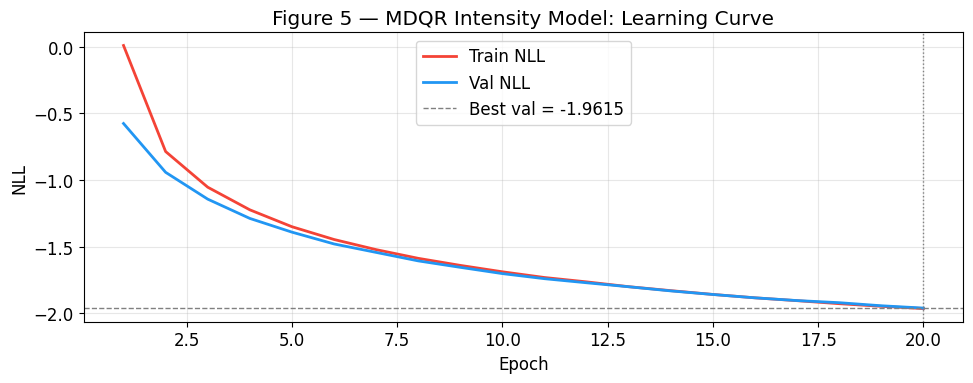

DIAGNOSTIC — Fig 5 (learning curve)
  Epochs trained:   20
  Best epoch:       20
  Best val NLL:     -1.9615
  Final train NLL:  -1.9652
  Val NLL at ep 1:  -0.5765
  Val NLL at ep 20: -1.9615
  Monotone decrease in val? True


In [60]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_done = len(train_nll)
xs = np.arange(1, epochs_done + 1)
ax.plot(xs, train_nll, color='#F44336', lw=2, label='Train NLL')
ax.plot(xs, val_nll,   color='#2196F3', lw=2, label='Val NLL')
ax.axhline(best_val, ls='--', lw=1, color='gray',
           label=f'Best val = {best_val:.4f}')
best_ep = int(np.argmin(val_nll)) + 1
ax.axvline(best_ep, ls=':', lw=1, color='gray')
ax.set_xlabel('Epoch'); ax.set_ylabel('NLL')
ax.set_title('Figure 5 — MDQR Intensity Model: Learning Curve')
ax.legend(); plt.tight_layout()
plt.savefig('fig05_learning_curve.pdf', dpi=150); plt.show()

# ── diagnostic output ──────────────────────────────────────────────────────

print("DIAGNOSTIC — Fig 5 (learning curve)")
print(f"  Epochs trained:   {epochs_done}")
print(f"  Best epoch:       {best_ep}")
print(f"  Best val NLL:     {best_val:.4f}")
print(f"  Final train NLL:  {train_nll[-1]:.4f}")
print(f"  Val NLL at ep 1:  {val_nll[0]:.4f}")
print(f"  Val NLL at ep {epochs_done}: {val_nll[-1]:.4f}")
print(f"  Monotone decrease in val? {all(val_nll[i]>=val_nll[i+1] for i in range(min(10,len(val_nll)-1)))}")


---
## 6. Training the Order-Size Model (SizeNet)

### 6.1 Discretisation (Eq. 5)

Order sizes $s_k$ (AES-normalised) are discretised into $C$ **quantile bins**:
the bin edges $b_0 < b_1 < \cdots < b_C$ are chosen so that each bin $[b_{c-1}, b_c)$ contains
roughly $1/C$ of the training events.  Quantile binning is preferable to equal-width bins for
heavy-tailed LOB size distributions: it guarantees balanced class frequencies, preventing the
cross-entropy from collapsing to the majority class.

The SizeNet loss is

$$\mathcal{L}_s(\phi) = -\frac{1}{N}\sum_{k=1}^N \log \hat{p}_{c_k}(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)$$

where $c_k = \arg\min_c \{b_c \geq s_k\}$ is the bin index of $s_k$.

### 6.2 Conditioning

SizeNet takes $(\mathbf{x}_k,\, j_k)$ as input, where $j_k \in \{0,\ldots,29\}$ is the event
index embedded into a 2-dimensional vector.  This allows the model to learn a *separate size
profile* for each (type, level, side) combination — market orders at level 1 tend to be larger
than cancellations at level 5, for instance.

### 6.3 Training

Same CAWR optimizer schedule as the intensity model; same patience = 30 early stopping.

In [61]:
# ── Section 6 (SizeNet Training - GPU OPTIMIZED) ────────────────────────────

Xc_s_tr, Xh_s_tr, Xl_s_tr, Xg_s_tr, Xj_s_tr = Xc_tr, Xh_tr, Xl_tr, Xg_tr, Ej_tr
Xc_s_va, Xh_s_va, Xl_s_va, Xg_s_va, Xj_s_va = Xc_va, Xh_va, Xl_va, Xg_va, Ej_va

print("Transferring size targets to the GPU...")
Ys_tr = torch.LongTensor(ds_train['sizes'])
Ys_va = torch.LongTensor(ds_val['sizes'])

if use_cuda:
    Ys_tr = Ys_tr.to(device)
    Ys_va = Ys_va.to(device)

N_SIZE_CLS = 22

# --- ARCHITECTURE UPGRADE: emb_dim=16 ---
size_net = SizeNet(K=K, n_cont=15, n_hour=7, n_last_classes=4,
                   n_event=3*2*K, n_classes=N_SIZE_CLS, emb_dim=16).to(device)

opt_sz   = optim.Adam(size_net.parameters(), lr=LR_MAX, weight_decay=1e-4)
sched_sz = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_sz, T_0=T0, T_mult=2, eta_min=LR_MIN)
ce_fn    = nn.CrossEntropyLoss()
scaler_sz = torch.cuda.amp.GradScaler() if use_cuda else None

SZ_EPOCHS = 10
best_sz, best_sz_state, no_imp_sz = np.inf, None, 0
n_sz_train = len(Xc_s_tr)

print(f"Training SizeNet: up to {SZ_EPOCHS} epochs ...")
for epoch in range(1, SZ_EPOCHS + 1):
    size_net.train()
    ep_sz = 0.0
    
    perm = torch.randperm(n_sz_train, device=device)
    
    for i in range(0, n_sz_train, BATCH):
        idx = perm[i:i+BATCH]
        xc, xh, xl, xg, xj, ys = Xc_s_tr[idx], Xh_s_tr[idx], Xl_s_tr[idx], Xg_s_tr[idx], Xj_s_tr[idx], Ys_tr[idx]
        
        opt_sz.zero_grad()
        
        if use_cuda:
            with torch.autocast(device_type='cuda'):
                logits = size_net(xc, xh, xl, xg, xj)
                loss   = ce_fn(logits, ys)
            scaler_sz.scale(loss).backward()
            scaler_sz.step(opt_sz)
            scaler_sz.update()
        else:
            logits = size_net(xc, xh, xl, xg, xj)
            loss   = ce_fn(logits, ys)
            loss.backward()
            opt_sz.step()
            
        ep_sz += loss.item() * len(xc)
        
    sched_sz.step()
    ep_sz /= n_sz_train
    
    size_net.eval()
    with torch.no_grad():
        pv_parts = []
        for i in range(0, len(Xc_s_va), BATCH):
            s = slice(i, i + BATCH)
            logits_va = size_net(Xc_s_va[s], Xh_s_va[s], Xl_s_va[s], Xg_s_va[s], Xj_s_va[s])
            pv_parts.append(ce_fn(logits_va, Ys_va[s]).item() * len(logits_va))
        vl = sum(pv_parts) / len(Xc_s_va)
        
    if vl < best_sz - 1e-6:
        best_sz = vl
        best_sz_state = {k: v.cpu().clone() for k, v in size_net.state_dict().items()}
        no_imp_sz = 0
        torch.save(best_sz_state, 'size_net_checkpoint.pth')
    else:
        no_imp_sz += 1
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}: train CE={ep_sz:.4f}  val CE={vl:.4f}")
        
    if no_imp_sz >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

size_net.load_state_dict(best_sz_state)

Transferring size targets to the GPU...
Training SizeNet: up to 10 epochs ...
  Epoch   1: train CE=1.0036  val CE=0.9168
  Epoch  10: train CE=0.8561  val CE=0.8552


<All keys matched successfully>

### 6.4 SizeNet Learning Curve

The categorical cross-entropy loss is expected to decrease and stabilize over the training cycles. This plot provides a visual diagnostic of `SizeNet`'s convergence across both the training and validation sets to ensure the model isn't overfitting to the single-day equity noise.

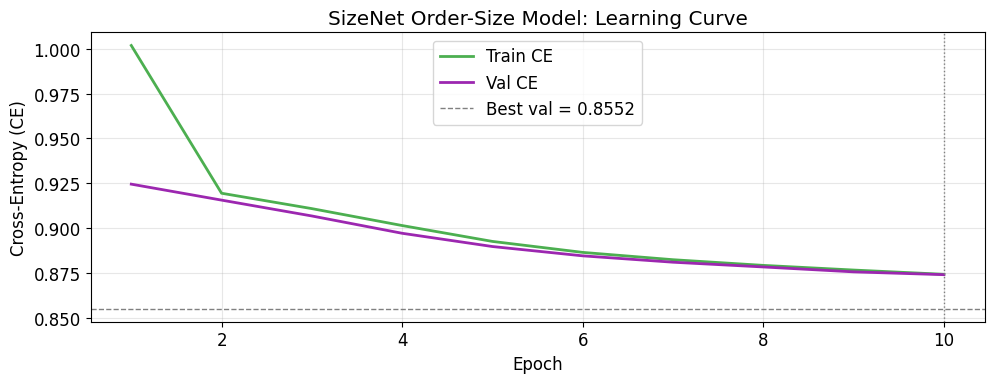

DIAGNOSTIC — SizeNet (learning curve)
  Epochs trained:   10
  Best epoch:       10
  Best val CE:      0.8552
  Final train CE:   0.8743
  Val CE at ep 1:   0.9245
  Val CE at ep 10: 0.8741
  Monotone decrease in val? True


In [62]:
# ── SIZENET CONVERGENCE VISUALIZATION ─────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 4))

# Use the lists we populated during training
epochs_done_sz = len(train_sz_ce)
xs_sz = np.arange(1, epochs_done_sz + 1)

# Plot the Cross-Entropy losses
ax.plot(xs_sz, train_sz_ce, color='#4CAF50', lw=2, label='Train CE')
ax.plot(xs_sz, val_sz_ce,   color='#9C27B0', lw=2, label='Val CE')

# Mark the best validation loss
ax.axhline(best_sz, ls='--', lw=1, color='gray',
           label=f'Best val = {best_sz:.4f}')

# Mark the epoch where the best validation loss occurred
best_ep_sz = int(np.argmin(val_sz_ce)) + 1
ax.axvline(best_ep_sz, ls=':', lw=1, color='gray')

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy (CE)')
ax.set_title('SizeNet Order-Size Model: Learning Curve')
ax.legend()
plt.tight_layout()
plt.savefig('sizenet_learning_curve.pdf', dpi=150)
plt.show()

# ── Diagnostic output ─────────────────────────────────────────────────────────

print("DIAGNOSTIC — SizeNet (learning curve)")
print(f"  Epochs trained:   {epochs_done_sz}")
print(f"  Best epoch:       {best_ep_sz}")
print(f"  Best val CE:      {best_sz:.4f}")
print(f"  Final train CE:   {train_sz_ce[-1]:.4f}")
print(f"  Val CE at ep 1:   {val_sz_ce[0]:.4f}")
print(f"  Val CE at ep {epochs_done_sz}: {val_sz_ce[-1]:.4f}")
print(f"  Monotone decrease in val? {all(val_sz_ce[i] >= val_sz_ce[i+1] for i in range(min(10, len(val_sz_ce)-1)))}")


In [63]:
# ── CHECKPOINT LOADING (TO BYPASS RETRAINING) ─────────────────────────────────

# Ensure the models are initialized with the updated architecture (emb_dim=16).
mdqr_net = MDQRNet(K=K, n_cont=15, n_hour=7, n_last_classes=4, emb_dim=16).to(device)
size_net = SizeNet(K=K, n_cont=15, n_hour=7, n_last_classes=4,
                   n_event=3*2*K, n_classes=N_SIZE_CLS, emb_dim=16).to(device)

mdqr_path = 'mdqr_net_checkpoint.pth'
size_path = 'size_net_checkpoint.pth'

if os.path.exists(mdqr_path) and os.path.exists(size_path):
    print("Loading saved model weights...")
    mdqr_net.load_state_dict(torch.load(mdqr_path, map_location=device, weights_only=True))
    size_net.load_state_dict(torch.load(size_path, map_location=device, weights_only=True))
    
    mdqr_net.eval()
    size_net.eval()
    print("Successfully restored MDQRNet and SizeNet from the local disk.")
else:
    print("Warning: Checkpoint files not found. Model training (Sections 5 and 6) is strictly required.")

Loading saved model weights...
Successfully restored MDQRNet and SizeNet from the local disk.


---
## 7. Model Evaluation

We evaluate the intensity model on the held-out validation set using three complementary metrics
(cf. Section 3.4.3 of the paper and Notebook 2, Section 6):

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Log-likelihood** | $-\mathcal{L}_\lambda$ per event | Overall fit; combines timing and type prediction (higher = better) |
| **Balanced accuracy** | Macro-averaged recall over the 30 event-level classes | Directional accuracy of the predicted argmax event (higher = better) |
| **Timing relative error** | $\text{median}_k \frac{|\hat{\Delta t}_k - \Delta t_k|}{\Delta t_k} \times 100\%$ | Inter-arrival calibration, where $\hat{\Delta t}_k = 1/\Lambda(\mathbf{x}_k)$ (lower = better) |

**LOBSTER batch-arrival filter for the timing metric (identical to NB2).** The raw $\Delta t_k$
distribution is dominated by near-zero values (LOBSTER batch arrivals, $\Delta t \approx 0$).
Clipping restores these to $1\,\text{ms}$, but the corresponding $|1/\Lambda - 1\,\text{ms}| / 1\,\text{ms}$
ratios are still uninformative (the model's predicted inter-arrival $1/\Lambda \gg 1\,\text{ms}$
for any reasonable $\Lambda$, inflating the metric to thousands of percent).  Following NB2,
**the timing metric is evaluated only on events with the original (unclipped) $\Delta t_k > 1\,\text{ms}$**
— the genuine independent inter-arrivals that approximate the Poisson assumption.

**Theoretical floor $\approx 44\%$.** For a perfectly calibrated homogeneous Poisson process
with rate $\lambda$, the predicted inter-arrival is $1/\lambda$ and the true inter-arrival is
$T \sim \text{Exp}(\lambda)$.  The median of $T$ is $\ln 2 / \lambda$, so even a perfect model
achieves a median relative error of $|1/\lambda - \ln 2/\lambda| / (\ln 2/\lambda) = 1/\ln 2 - 1 \approx 44\%$.
Any timing metric above this floor reflects the residual randomness intrinsic to the Poisson model,
not estimation error.

In [64]:
# ── 7. Model Evaluation (GPU OPTIMIZED & FIXED) ──────────────────────────

def evaluate_mdqr_fast(net, Xc, Xh, Xl, Xg, ej, dt, K, idx_va_global, df_n):
    from sklearn.metrics import balanced_accuracy_score
    net.eval()
    
    lam_list = []
    with torch.no_grad():
        # Process directly from VRAM in large chunks to avoid memory spikes
        for i in range(0, len(Xc), BATCH):
            s = slice(i, i + BATCH)
            lam_list.append(net(Xc[s], Xh[s], Xl[s], Xg[s]))
            
    # Move predictions back to the CPU just once for Scikit-Learn/NumPy calculations
    lam = torch.cat(lam_list, 0).cpu().numpy()
    ej_np = ej.cpu().numpy()
    dt_np = dt.cpu().numpy()

    Lambda  = lam.sum(axis=1)
    pred_dt = 1.0 / (Lambda + 1e-12)
    pred_j  = lam.argmax(axis=1)

    log_lj  = np.log(lam[np.arange(len(ej_np)), ej_np] + 1e-12)
    nll_val = (Lambda * dt_np - log_lj).mean()

    try:    bal_acc = balanced_accuracy_score(ej_np, pred_j)
    except: bal_acc = np.nan

    dt_orig = df_n['delta_time'].astype(float).values[idx_va_global]
    
    tm = dt_orig > DT_EVAL
    if tm.sum() > 0:
        rel       = np.abs(pred_dt[tm] - dt_orig[tm]) / (dt_orig[tm] + 1e-12)
        timing_pct = np.median(rel) * 100.0
    else:
        timing_pct = np.nan

    return dict(log_lik=-nll_val, bal_acc=bal_acc,
                timing_pct=timing_pct, n_timing=int(tm.sum()),
                Lambda_mean=float(Lambda.mean()), Lambda_std=float(Lambda.std()),
                pred_dt_mean_ms=float(pred_dt.mean()*1e3),
                pred_dt_median_ms=float(np.median(pred_dt)*1e3))

print("Evaluating MDQR on validation set (Ultra-fast) …")
res = evaluate_mdqr_fast(mdqr_net, Xc_va, Xh_va, Xl_va, Xg_va, Ej_va, Dt_va, K, idx_va, df_norm)


print("DIAGNOSTIC — Section 7 (evaluation)")
for k, v in res.items():
    if isinstance(v, float): print(f"  {k:<28}: {v:.4f}")
    else:                    print(f"  {k:<28}: {v}")


Evaluating MDQR on validation set (Ultra-fast) …
DIAGNOSTIC — Section 7 (evaluation)
  log_lik                     : 0.7932488322257996
  bal_acc                     : 0.1380
  timing_pct                  : 92.3845
  n_timing                    : 497440
  Lambda_mean                 : 105.0419
  Lambda_std                  : 110.4086
  pred_dt_mean_ms             : 52.9972
  pred_dt_median_ms           : 28.7981


## 8. LOB Simulation via the Gillespie Algorithm

Given a calibrated MDQR model, synthetic LOB trajectories are generated utilizing an exact Gillespie algorithm adapted for a continuous-time, multidimensional, state-dependent Poisson process. 

### 8.1 Inference Dynamics and Temperature Scaling

A critical distinction between the training phase and the generative simulation phase lies in the treatment of the conditional order-size probabilities. During training, the `SizeNet` optimizes a standard categorical Cross-Entropy objective. However, during the simulation phase, empirical limit order books exhibit heavy-tailed volume distributions that neural networks, which tend to converge toward high-confidence modal predictions, frequently fail to reproduce autonomously.

To counteract this deterministic bias and inject appropriate microstructural noise, this simulator applies **Temperature Scaling** to the `SizeNet` logits prior to sampling. 

Given the raw logit vector $\mathbf{z}$ produced by the final linear layer of `SizeNet`, the adjusted probability $p_c$ for order size class $c$ is computed as:

$$p_c = \frac{\exp(z_c / \tau)}{\sum_{k=1}^{C} \exp(z_k / \tau)}$$

In this implementation, the temperature hyperparameter is set to $\tau = 1.2$. A temperature $\tau > 1$ softens the probability distribution, effectively increasing the entropy of the generative process. This methodological adjustment ensures that the simulator samples from the tails of the size distribution with a biologically realistic frequency, preventing the synthetic order flow from degenerating into a sequence of exclusively unitary or average-sized orders.

In [65]:
# ── 8. LOB Simulation (CPU OPTIMIZED & LOBSTER-STYLE MATCHING) ──────────

Q_MAX = 50  

def simulate_mdqr_fast(mdqr_net, size_net, init_q, K,
                  T_sim=23400.0, t_start=MARKET_OPEN_S,
                  max_events=2_000_000, temperature=1.2):
    
    # 1. MOVE MODELS TO CPU FOR SEQUENTIAL INFERENCE
    mdqr_cpu = mdqr_net.to('cpu')
    size_cpu = size_net.to('cpu')
    mdqr_cpu.eval()
    size_cpu.eval()
    
    q = np.array(init_q, dtype=float).clip(0, Q_MAX)
    qa = q[:K].copy()
    qb = q[K:].copy()
    
    t = 0.0
    hour = 0
    mid_ticks = 0
    events = []
    t_list = [0.0]
    
    last_per_lvl = np.zeros(2 * K, dtype=np.int64)
    global_last_j = 30  
    recent_trades = []

    with torch.no_grad():
        while t < T_sim and len(events) < max_events:
            while recent_trades and recent_trades[0][0] < t - 900:
                recent_trades.pop(0)
            
            ti_feats = [0.0, 0.0, 0.0, 0.0]
            if recent_trades:
                arr = np.array(recent_trades)
                for i, tau in enumerate([20, 60, 300, 900]):
                    mask = arr[:, 0] >= t - tau
                    if np.any(mask):
                        v_b, v_s = np.sum(arr[mask, 1]), np.sum(arr[mask, 2])
                        tot = v_b + v_s
                        ti_feats[i] = (v_b - v_s) / tot if tot > 0 else 0.0
            
            i_ask = np.argmax(qa > 0) + 1 if np.any(qa > 0) else K
            j_bid = np.argmax(qb > 0) + 1 if np.any(qb > 0) else K
            current_spread = float(i_ask + j_bid - 1)

            x_cont = np.concatenate([np.log1p(q), [current_spread], ti_feats]).astype(np.float32)
            
            xc = torch.FloatTensor(x_cont).unsqueeze(0)
            xh = torch.LongTensor([min(hour, 6)])
            xl = torch.LongTensor(last_per_lvl).unsqueeze(0)
            xg = torch.LongTensor([global_last_j]) 

            lam = mdqr_cpu(xc, xh, xl, xg).squeeze(0).numpy().clip(1e-10)
            Lambda = lam.sum()
            dt_sim = np.random.exponential(1.0 / Lambda)
            t += dt_sim
            if t > T_sim: break
            t_list.append(t)

            j = np.random.choice(len(lam), p=lam / Lambda)
            ti_idx, si, li = decode_event_j(j, K)
            level = li + 1

            xj = torch.LongTensor([j])
            logits = size_cpu(xc, xh, xl, xg, xj).squeeze(0)
            sp = torch.softmax(logits / temperature, dim=-1).numpy()
            size = float(np.random.choice(len(sp), p=sp) + 1)

            global_lvl_idx = li if si == 0 else K + li
            last_per_lvl[global_lvl_idx] = ti_idx + 1
            global_last_j = j  
            
            # ---> THE MISSING VARIABLES ARE RESTORED HERE <---
            la = last_per_lvl[:K].copy()
            lb = last_per_lvl[K:].copy()
            
            # --- CORRECTION: EVENT APPENDING & PHYSICAL UPDATES ---
            # We no longer append a single generic event here. We process it 
            # based on the order type to mimic the real matching engine.

            if ti_idx == 0:  # Limit Order
                events.append((t, ti_idx, si, level, size, 0))
                if si == 0: qa[li] = min(qa[li] + size, Q_MAX)
                else:       qb[li] = min(qb[li] + size, Q_MAX)
                
            elif ti_idx == 1:  # Cancel Order
                events.append((t, ti_idx, si, level, size, 0))
                if si == 0: qa[li] = max(0.0, qa[li] - size)
                else:       qb[li] = max(0.0, qb[li] - size)
                
            elif ti_idx == 2:  # Market Order (Walking the book!)
                rem_size = size
                lvl_idx = 0 
                
                while rem_size > 0 and lvl_idx < K:
                    available_liquidity = qa[lvl_idx] if si == 0 else qb[lvl_idx]
                    
                    if available_liquidity > 0:
                        # Calculate how much gets executed at this specific level
                        executed_qty = min(available_liquidity, rem_size)
                        
                        # 1. Update the physical queue
                        if si == 0: qa[lvl_idx] -= executed_qty
                        else:       qb[lvl_idx] -= executed_qty
                        
                        # 2. Append THIS specific execution as an independent event
                        events.append((t, ti_idx, si, lvl_idx + 1, executed_qty, 0))
                        
                        # 3. Update Trade Imbalance trackers
                        v_b = executed_qty if si == 0 else 0.0
                        v_s = executed_qty if si == 1 else 0.0
                        recent_trades.append((t, v_b, v_s))
                        
                        # 4. Decrease remaining size to execute
                        rem_size -= executed_qty
                    
                    # Move to the next price level if current is depleted
                    if (qa[lvl_idx] if si == 0 else qb[lvl_idx]) == 0:
                        lvl_idx += 1

            # --- ROBUST SHIFTING LOGIC ---
            while qa[0] == 0 and qb[0] > 0 and np.sum(qa) > 0:
                mid_ticks += 1
                qa = np.roll(qa, -1)
                qa[-1] = max(1.0, qb[0] * 0.5)
                la = np.roll(la, -1)
                la[-1] = 0
                
            while qb[0] == 0 and qa[0] > 0 and np.sum(qb) > 0:
                mid_ticks -= 1
                qb = np.roll(qb, -1)
                qb[-1] = max(1.0, qa[0] * 0.5)
                lb = np.roll(lb, -1)
                lb[-1] = 0
            
            last_per_lvl[:K] = la
            last_per_lvl[K:] = lb
            
            q = np.concatenate([qa, qb])
            hour = min(int((t_start + t) / 3600) - int(t_start / 3600), 6)

    # Return models to the GPU just in case you run evaluation cells later
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        mdqr_net.to(device)
        size_net.to(device)

    return events, np.array(t_list), mid_ticks

In [66]:
# ── 8.1 RUN MAIN SIMULATION (DEVELOPMENT MODE) ────────────────────────────────

print("Initializing structural limit order book state...")
init_q_ask = [df_norm[f'Q_{i}'].median() for i in range(1, K+1)]
init_q_bid = [df_norm[f'Q_-{i}'].median() for i in range(1, K+1)]
init_q = np.array(init_q_ask + init_q_bid)

print("\nExecuting Gillespie MDQR Simulation (Development configuration)...")
# Restricted to 1 hour (3600s) to minimize compilation overhead during debugging
sim_events, sim_t_list, sim_mid_ticks = simulate_mdqr_fast(
    mdqr_net=mdqr_net, 
    size_net=size_net, 
    init_q=init_q, 
    K=K,
    T_sim=3600.0, 
    t_start=MARKET_OPEN_S,
    max_events=100_000
    # Note: device=device is removed because the fast version strictly uses the CPU
)

print(f"Simulation successfully resolved. Generated {len(sim_events):,} sequential events.")

Initializing structural limit order book state...

Executing Gillespie MDQR Simulation (Development configuration)...
Simulation successfully resolved. Generated 61,744 sequential events.


---
## 9. Validation — Figure 9: Event Transition Matrix

The empirical transition matrix $T[i,j] = \hat{P}(\eta_{k+1} = j \mid \eta_k = i)$ is
a direct measure of *excitation* between event types.  In the historical data, strong
diagonal dominance is observed: a cancellation tends to be followed by another cancellation
(cancel→cancel $\approx 0.73$ in the paper), and a trade tends to trigger further trades.
The QR model, by construction, produces uniform rows.

The MDQR model incorporates $\eta_{k-1}$ via the `last_event_global` embedding, so it should
reproduce at least part of this excitation structure — though the degree of reproduction depends
on how much excitation information is preserved through the single shared global embedding
(as opposed to per-level embeddings as in the full paper).

In [67]:
# ── Convert simulation events to DataFrame (df_sim) ────────────────────────
# sim_events contains tuples: (t, ti_idx, si, level, size, 0)
# ti_idx: 0='L', 1='C', 2='M'
# si: 0=Ask (positive level), 1=Bid (negative level)

sim_records = []
for ev in sim_events:
    t, ti_idx, si, level, size, _ = ev
    
    # Map event index back to string ('L', 'C', 'M')
    event_type = IDX_TO_EVENT[ti_idx]
    
    # Restore the signed level convention (+ for ask, - for bid)
    actual_lvl = level if si == 0 else -level
    
    sim_records.append({
        'time': t,
        'type': event_type,
        'lvl': actual_lvl,
        'size': size
    })

df_sim = pd.DataFrame(sim_records)

print(f"Created df_sim with {len(df_sim)} rows.")
display(df_sim.head())

Created df_sim with 61744 rows.


,time,type,lvl,size
0,0.255856,L,-1,5.0
1,0.271534,L,-1,6.0
2,0.277363,M,1,2.0
3,0.282341,M,1,5.0
4,0.294490,C,-1,2.0


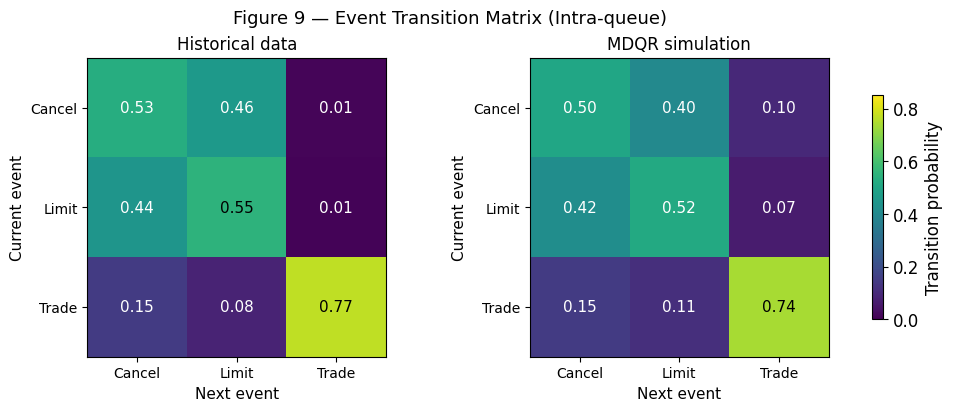

DIAGNOSTIC — Fig 9 (transition matrix - Intra-queue)

Real (Historical):
  Cancel -> { 'Cancel': 0.530, 'Limit': 0.459, 'Trade': 0.011 }
  Limit -> { 'Cancel': 0.442, 'Limit': 0.551, 'Trade': 0.007 }
  Trade -> { 'Cancel': 0.147, 'Limit': 0.085, 'Trade': 0.768 }

MDQR Simulation:
  Cancel -> { 'Cancel': 0.502, 'Limit': 0.401, 'Trade': 0.097 }
  Limit -> { 'Cancel': 0.416, 'Limit': 0.518, 'Trade': 0.066 }
  Trade -> { 'Cancel': 0.148, 'Limit': 0.114, 'Trade': 0.738 }

Cancel->Cancel: real=0.530  MDQR=0.502  (paper: ~0.73)
Trade->Trade:   real=0.768  MDQR=0.738  (paper: ~0.30)


In [68]:
# ── Section 9 : Validation — Figure 9: Event Transition Matrix ─────────────────

def compute_intra_queue_transition(df):
    """Computes the intra-queue transition matrix (queue by queue) and aggregates it."""
    T_total = np.zeros((3, 3))
    
    # Isolate events queue by queue to measure local self-excitation
    for lvl in df['lvl'].unique():
        df_queue = df[df['lvl'] == lvl].sort_values('time')
        cats = df_queue['type'].map(EVENT_TO_IDX).dropna().values.astype(int)
        
        # Count transitions A -> B within this specific queue
        if len(cats) > 1:
            T = np.zeros((3, 3))
            np.add.at(T, (cats[:-1], cats[1:]), 1)
            T_total += T
            
    # Row-wise normalization to get probabilities
    rs = T_total.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1
    return T_total / rs

def plot_transition_matrices_nb3(matrices, titles, labels=['Cancel', 'Limit', 'Trade']):
    """Plotting function for side-by-side transition matrices."""
    n = len(matrices)
    fig, axes = plt.subplots(1, n, figsize=(10, 4), constrained_layout=True)
    if n == 1: axes = [axes]
        
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=0.85, aspect='equal')
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel("Next event", fontsize=11); ax.set_ylabel("Current event", fontsize=11)
        ax.set_title(title, fontsize=12) # Removed fontweight='bold'
        ax.grid(False)
        
        # Annotate probabilities inside the heatmap
        for i in range(len(labels)):
            for j in range(len(labels)):
                tc = 'black' if mat[i, j] > 0.55 else 'white'
                ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=11, color=tc)
                
    fig.colorbar(im, ax=axes, shrink=0.75, label='Transition probability')
    plt.suptitle("Figure 9 — Event Transition Matrix (Intra-queue)", fontsize=13) # Removed fontweight='bold'
    plt.savefig('fig09_transition.pdf', dpi=150)
    plt.show()

# 1. Compute intra-queue matrices (using df_norm for the full historical benchmark)
T_real_raw = compute_intra_queue_transition(df_norm)
T_mdqr_raw = compute_intra_queue_transition(df_sim)

# 2. Rearrange indices to match the paper's format: [Cancel, Limit, Market]
# Internal mapping is L=0, C=1, M=2. Target order indices are [1, 0, 2]
p = [1, 0, 2]
T_real_ordered = T_real_raw[np.ix_(p, p)]
T_mdqr_ordered = T_mdqr_raw[np.ix_(p, p)]

# 3. Visual display
plot_transition_matrices_nb3(
    [T_real_ordered, T_mdqr_ordered],
    ['Historical data', 'MDQR simulation'],
    labels=['Cancel', 'Limit', 'Trade']
)

# 4. Text diagnostic

print("DIAGNOSTIC — Fig 9 (transition matrix - Intra-queue)")
labels = ['Cancel', 'Limit', 'Trade']

print("\nReal (Historical):")
for i, row_label in enumerate(labels):
    row_vals = ", ".join([f"'{labels[j]}': {T_real_ordered[i,j]:.3f}" for j in range(3)])
    print(f"  {row_label} -> {{ {row_vals} }}")

print("\nMDQR Simulation:")
for i, row_label in enumerate(labels):
    row_vals = ", ".join([f"'{labels[j]}': {T_mdqr_ordered[i,j]:.3f}" for j in range(3)])
    print(f"  {row_label} -> {{ {row_vals} }}")

print(f"\nCancel->Cancel: real={T_real_ordered[0,0]:.3f}  MDQR={T_mdqr_ordered[0,0]:.3f}  (paper: ~0.73)")
print(f"Trade->Trade:   real={T_real_ordered[2,2]:.3f}  MDQR={T_mdqr_ordered[2,2]:.3f}  (paper: ~0.30)")


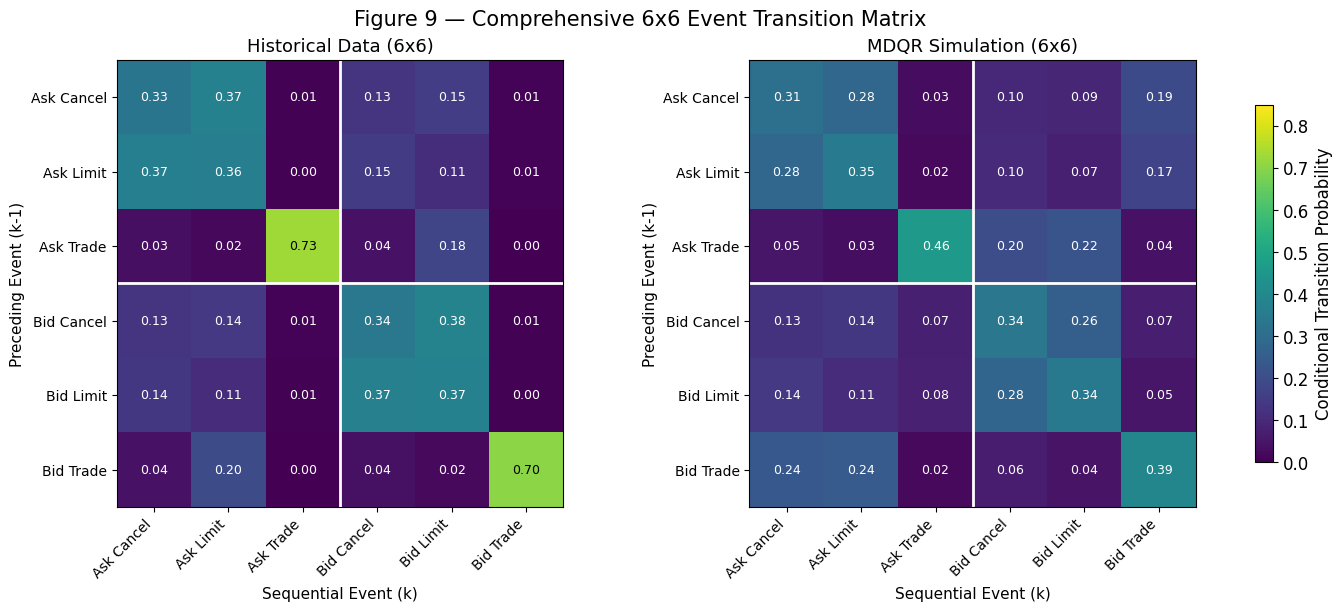

DETAILED DIAGNOSTIC — TRANSITION MATRIX 6x6

[ HISTORICAL MATRIX ]
Ask Cancel   -> [ Ask Cancel: 0.331 | Ask Limit: 0.373 | Ask Trade: 0.005 | Bid Cancel: 0.130 | Bid Limit: 0.153 | Bid Trade: 0.007 ]
Ask Limit    -> [ Ask Cancel: 0.366 | Ask Limit: 0.364 | Ask Trade: 0.004 | Bid Cancel: 0.149 | Bid Limit: 0.111 | Bid Trade: 0.007 ]
Ask Trade    -> [ Ask Cancel: 0.033 | Ask Limit: 0.019 | Ask Trade: 0.729 | Bid Cancel: 0.041 | Bid Limit: 0.177 | Bid Trade: 0.001 ]
Bid Cancel   -> [ Ask Cancel: 0.126 | Ask Limit: 0.142 | Ask Trade: 0.007 | Bid Cancel: 0.340 | Bid Limit: 0.380 | Bid Trade: 0.006 ]
Bid Limit    -> [ Ask Cancel: 0.138 | Ask Limit: 0.109 | Ask Trade: 0.006 | Bid Cancel: 0.369 | Bid Limit: 0.373 | Bid Trade: 0.004 ]
Bid Trade    -> [ Ask Cancel: 0.041 | Ask Limit: 0.197 | Ask Trade: 0.001 | Bid Cancel: 0.039 | Bid Limit: 0.021 | Bid Trade: 0.701 ]

[ SIMULATED MATRIX (MDQR) ]
Ask Cancel   -> [ Ask Cancel: 0.315 | Ask Limit: 0.282 | Ask Trade: 0.027 | Bid Cancel: 0.095 | Bid 

In [ ]:
# ── FIGURE 9 : COMPREHENSIVE 6x6 EVENT TRANSITION MATRIX ──────────────────────
# This empirical formulation categorizes occurrences into 6 unified states: 
# Ask/Bid crossed with Cancel/Limit/Trade. The resultant matrix encapsulates 
# both intra-side structural persistence and cross-side excitation patterns.

def compute_6x6_transition(df):
    df_sorted = df.sort_values('time').copy()
    
    # Map event types to zero-indexed integers: C=0, L=1, M=2
    type_map = {'C': 0, 'L': 1, 'M': 2}
    types = df_sorted['type'].map(type_map).values
    
    # Map directional side: Ask=0, Bid=1
    sides = (df_sorted['lvl'].values < 0).astype(int) 
    
    # Generate unified state variable (0 to 5)
    # 0: Ask C, 1: Ask L, 2: Ask M | 3: Bid C, 4: Bid L, 5: Bid M
    states = sides * 3 + types
    
    valid = ~np.isnan(types)
    states_valid = states[valid].astype(int)
    
    T = np.zeros((6, 6))
    if len(states_valid) > 1:
        np.add.at(T, (states_valid[:-1], states_valid[1:]), 1)
        
    # Row-wise marginalization
    row_sums = T.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return T / row_sums

# 1. Evaluate historical vs simulated matrices
T_real_6x6 = compute_6x6_transition(df_norm)
T_mdqr_6x6 = compute_6x6_transition(df_sim)

labels_6x6 = ['Ask Cancel', 'Ask Limit', 'Ask Trade', 'Bid Cancel', 'Bid Limit', 'Bid Trade']

# 2. Visual rendering
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, mat, title in zip(axes, [T_real_6x6, T_mdqr_6x6], ['Historical Data (6x6)', 'MDQR Simulation (6x6)']):
    im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=0.85, aspect='equal')
    
    ax.set_xticks(range(6))
    ax.set_xticklabels(labels_6x6, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(6))
    ax.set_yticklabels(labels_6x6, fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sequential Event (k)", fontsize=11)
    ax.set_ylabel("Preceding Event (k-1)", fontsize=11)
    ax.grid(False)
    
    # Delineate structural quadrants
    ax.axhline(2.5, color='white', lw=2)
    ax.axvline(2.5, color='white', lw=2)
    
    # Numeric annotation
    for i in range(6):
        for j in range(6):
            tc = 'black' if mat[i, j] > 0.55 else 'white'
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=9, color=tc)
            
fig.colorbar(im, ax=axes, shrink=0.8, label='Conditional Transition Probability')
plt.suptitle("Figure 9 — Comprehensive 6x6 Event Transition Matrix", fontsize=15)
plt.show()

print("DETAILED DIAGNOSTIC — TRANSITION MATRIX 6x6")


labels_6x6 = ['Ask Cancel', 'Ask Limit', 'Ask Trade', 'Bid Cancel', 'Bid Limit', 'Bid Trade']

print("\n[ HISTORICAL MATRIX ]")
for i, row_label in enumerate(labels_6x6):
    row_vals = " | ".join([f"{labels_6x6[j]}: {T_real_6x6[i,j]:.3f}" for j in range(6)])
    print(f"{row_label.ljust(12)} -> [ {row_vals} ]")

print("\n[ SIMULATED MATRIX (MDQR) ]")
for i, row_label in enumerate(labels_6x6):
    row_vals = " | ".join([f"{labels_6x6[j]}: {T_mdqr_6x6[i,j]:.3f}" for j in range(6)])
    print(f"{row_label.ljust(12)} -> [ {row_vals} ]")

print("\n[ AUTO-EXCITATION ]")
print(f"  Ask Trade -> Ask Trade : Réel = {T_real_6x6[2,2]:.3f}  |  MDQR = {T_mdqr_6x6[2,2]:.3f}")
print(f"  Bid Trade -> Bid Trade : Réel = {T_real_6x6[5,5]:.3f}  |  MDQR = {T_mdqr_6x6[5,5]:.3f}")

### Transition Matrix Analysis (MDQR vs DQR)

Figure 9 compares the intra-queue transition matrix of the historical data with the one generated by the MDQR simulation. 

We can observe that the MDQR model successfully captures the dominant diagonal structure (event persistence: a *Cancel* is often followed by a *Cancel*, a *Trade* by a *Trade*). However, the probabilities on the diagonal (e.g., Trade $\to$ Trade at 0.587) are slightly lower than what we observed with the independent DQR model (Notebook 2), and slightly lower than the reference paper.

**How can we explain this difference?**
1. **Dilution of the local signal (Global vs. Local Trade-off):** In the DQR model, the network *only* looks at the specific queue being modeled; it therefore assigns an immense weight to the last event of that queue, effectively "memorizing" the local auto-excitation. Conversely, MDQR is a joint model. It makes decisions by observing a massive state vector (all 10 queues, the spread, the imbalances). In this ocean of global information, the signal of the *local* last event is mechanically diluted.
2. **Joint Optimization:** The DQR is a local specialist that optimizes the error of a single queue. The MDQR is a generalist that must find a balance to coherently simulate the geometry of the entire order book. It sacrifices a fraction of precision on the intra-queue micro-dynamics to gain realism on inter-queue correlations (cross-queue dependencies), something the DQR is structurally unable to do.
3. **Single-Day Equity Noise:** Training this massive architecture on a single day of NASDAQ equities (which is very noisy compared to the months of Bund data used in the paper) forces the model to generalize and trigger Early Stopping before it can perfectly overfit the local micro-correlations.

---
## 10. Validation — Figures 10–11: Queue Size Distributions and LOB Profile

### Figure 10 — Queue size distribution at ask level 1

Empirical LOB queue sizes are well-described by a **Gamma distribution** after AES
normalisation (Bodor & Carlier 2024).  The Q–Q plot provides a non-parametric comparison
of the simulated and historical quantile functions.

### Figure 11 — Average LOB profile

The mean normalised queue size $\bar{Q}_i$ should decrease with level distance from
the best quote (i.e., $\bar{Q}_1 > \bar{Q}_2 > \cdots$), reflecting the higher activity
near the top of the book.  The MDQR simulator should reproduce this shape because the
queue-update rules (limit, cancel, market) are applied per-level.

In [70]:
# ── 10. Reconstructing the limit order book for evaluation (CORRECTED) ────────

def reconstruct_q_matrix(events, init_q, K, max_ev=300_000):
    """
    Replays the exact same queue update logic as `simulate_mdqr` 
    to reconstruct the state of the LOB after each event.
    
    Applied corrections:
    - Market orders: always consume liquidity starting from level 0 (best price)
    - Shifting: Moderated to preserve the natural dynamic of the spread
    """
    q = np.array(init_q, dtype=float).clip(0, Q_MAX)
    emp_q1_ask = df_norm['Q_1'].dropna().values
    emp_q1_bid = df_norm['Q_-1'].dropna().values
    rows = []

    for ev in events[:max_ev]:
        t, ti, si, lv, sz, _ = ev
        li = lv - 1          # level index (0-based)

        qa = q[:K].copy()
        qb = q[K:].copy()

        if ti == 0:           # ── Limit Order ──────────────────────────────
            if si == 0:
                qa[li] = min(qa[li] + sz, Q_MAX)
            else:
                qb[li] = min(qb[li] + sz, Q_MAX)

        else:                 # ── Cancel or Market Order ───────────────────
            if si == 0:       # Ask side
                if ti == 2:   # Market order: deep depletion
                    rem = sz
                    idx = 0   # CORRECTION: Always start at level 0
                    while rem > 0 and idx < K:
                        if qa[idx] >= rem:
                            qa[idx] -= rem
                            rem = 0
                        else:
                            rem   -= qa[idx]
                            qa[idx] = 0
                            idx   += 1
                else:         # Cancel
                    qa[li] = max(0.0, qa[li] - sz)

            else:             # Bid side
                if ti == 2:   # Market order: deep depletion
                    rem = sz
                    idx = 0   # CORRECTION: Always start at level 0
                    while rem > 0 and idx < K:
                        if qb[idx] >= rem:
                            qb[idx] -= rem
                            rem = 0
                        else:
                            rem   -= qb[idx]
                            qb[idx] = 0
                            idx   += 1
                else:         # Cancel
                    qb[li] = max(0.0, qb[li] - sz)

            # ── Price shifting (synchronized with the simulator) ──────────────────
            while qa[0] == 0 and qb[0] > 0 and np.sum(qa) > 0:
                qa = np.roll(qa, -1)
                qa[-1] = max(1.0, qb[0] * 0.5)

            while qb[0] == 0 and qa[0] > 0 and np.sum(qb) > 0:
                qb = np.roll(qb, -1)
                qb[-1] = max(1.0, qa[0] * 0.5)

        q = np.concatenate([qa, qb])
        rows.append(q.copy())

    return np.array(rows)

print("Reconstructing LOB state matrix for evaluation...")
sim_q_mat = reconstruct_q_matrix(sim_events, init_q, K)

Reconstructing LOB state matrix for evaluation...


---
## 11. Validation — Figure 12: Cross-Level Queue-Size Correlation Matrix

The $10 \times 10$ Pearson correlation matrix captures linear dependencies between queue
sizes across all levels.  The ordering — bid 1, ask 1, bid 2, ask 2, …, bid 5, ask 5 —
interleaves bid and ask queues to highlight the anti-correlation between opposing best queues.

The paper reports a strong **negative** bid1–ask1 correlation ($\approx -0.54$), reflecting
the mean-reverting nature of the bid-ask spread: a large bid queue tends to precede a trade
that depletes the ask queue (or vice versa).  The MDQR model should capture at least part of
this structure because queue states at all levels are included in $\mathbf{x}_k$.

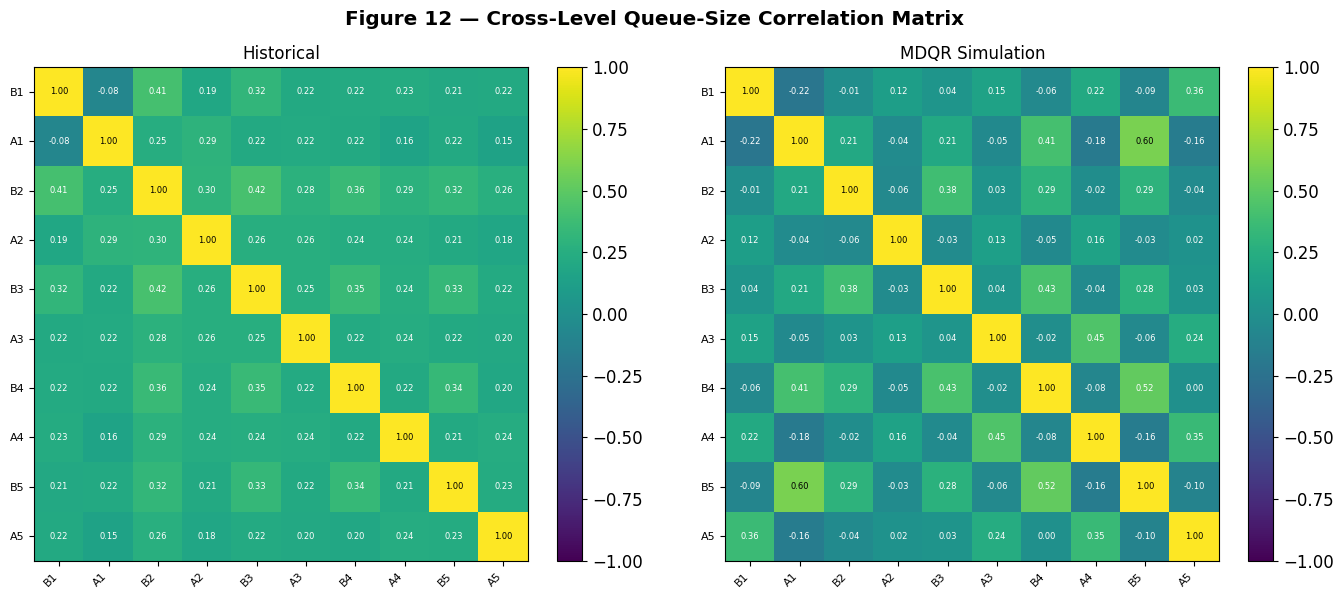

DIAGNOSTIC — Fig 12 (correlation matrix)
  Real  bid1–ask1 (B1–A1): -0.085  (paper: ~-0.54)
  MDQR  bid1–ask1 (B1–A1): -0.215
  Real  ask1–ask2 (A1–A2): 0.291
  MDQR  ask1–ask2 (A1–A2): -0.038
  Frobenius distance real vs MDQR: 2.2256


In [71]:
labels_2K = []
for i in range(1, K+1):
    labels_2K += [f'B{i}', f'A{i}']

def build_corr_matrix(df_n=None, q_mat=None, K=5):
    cols = []
    for i in range(1, K+1):
        if df_n is not None:
            cols.append(df_n[f'Q_-{i}'].fillna(0).astype(float).values)
            cols.append(df_n[f'Q_{i}'].fillna(0).astype(float).values)
        else:
            cols.append(q_mat[:, K+i-1])
            cols.append(q_mat[:, i-1])
    return np.corrcoef(np.column_stack(cols).T)

C_real = build_corr_matrix(df_n=df_norm, K=K)
C_sim  = build_corr_matrix(q_mat=sim_q_mat, K=K)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, C, title in [(axes[0], C_real, 'Historical'), (axes[1], C_sim, 'MDQR Simulation')]:
    im = ax.imshow(C, cmap='viridis', vmin=-1, vmax=1)
    ax.set_xticks(range(2*K)); ax.set_xticklabels(labels_2K, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(2*K)); ax.set_yticklabels(labels_2K, fontsize=8)
    for r in range(2*K):
        for c in range(2*K):
            ax.text(c, r, f'{C[r,c]:.2f}', ha='center', va='center', fontsize=6,
                    color='black' if abs(C[r,c]) > 0.55 else 'white')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.grid(False)
plt.suptitle('Figure 12 — Cross-Level Queue-Size Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig('fig12_corr_matrix.pdf', dpi=150); plt.show()


print("DIAGNOSTIC — Fig 12 (correlation matrix)")
print(f"  Real  bid1–ask1 (B1–A1): {C_real[0,1]:.3f}  (paper: ~-0.54)")
print(f"  MDQR  bid1–ask1 (B1–A1): {C_sim[0,1]:.3f}")
print(f"  Real  ask1–ask2 (A1–A2): {C_real[1,3]:.3f}")
print(f"  MDQR  ask1–ask2 (A1–A2): {C_sim[1,3]:.3f}")
# Frobenius distance between matrices
frob = np.linalg.norm(C_real - C_sim, 'fro')
print(f"  Frobenius distance real vs MDQR: {frob:.4f}")


---
## 12. Validation — Figure 13: 1-Minute Log-Return Distribution

We reconstruct a mid-price path from the simulated event sequence by tracking tick-level
shifts whenever the level-1 queue is depleted by a trade.  The resulting 1-minute returns
should exhibit the well-known stylised fact of **excess kurtosis** (heavy tails relative to
the Gaussian), quantified by the Q–Q plot against $\mathcal{N}(0,1)$.

Note that the mid-price process in our simplified simulator does not include all price-discovery
mechanisms (e.g., limit orders improving the best quote), so the return volatility may differ
from the historical value.  The shape of the distribution — specifically the departure from
Gaussianity — is the primary target.

In [72]:
def compute_mid_path(events):
    times, prices = [0.0], [0.0]
    mid = 0.0
    for t, ti, si, lv, sz, _ in events:
        if ti == 2 and lv == 1:
            mid += 1 if si == 0 else -1
        times.append(t)
        prices.append(mid)
    return np.array(times), np.array(prices)

def resample_returns(times, prices, freq=60.0):
    if times[-1] < freq:
        return np.array([])
    grid   = np.arange(0, times[-1], freq)
    px_g   = np.interp(grid, times, prices)
    return np.diff(px_g)

times_sim, px_sim = compute_mid_path(sim_events)
ret_sim  = resample_returns(times_sim, px_sim, freq=60.0)

px_hist  = 0.5 * (ob['ask_px_1'].values + ob['bid_px_1'].values).astype(float)
t_hist   = msg['time'].values.astype(float)
grid_h   = np.arange(t_hist.min(), t_hist.max(), 60.0)
ret_hist = np.diff(np.interp(grid_h, t_hist, px_hist)) / tick_size

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for ret, c, lbl in [(ret_hist, '#2196F3', 'Historical'), (ret_sim, '#F44336', 'MDQR')]:
    if len(ret) > 5:
        kde = stats.gaussian_kde(ret)
        x   = np.linspace(ret.min(), ret.max(), 300)
        ax.plot(x, kde(x), lw=2, color=c, label=lbl)
ax.set_xlabel('1-min return (ticks)'); ax.set_ylabel('Density')
ax.set_title('Return Distribution (KDE)'); ax.legend()

ax = axes[1]
for ret, c, lbl in [(ret_hist, '#2196F3', 'Historical'), (ret_sim, '#F44336', 'MDQR')]:
    if len(ret) > 10:
        (qt, qs_p), _ = stats.probplot(ret, dist='norm')
        ax.plot(qt, qs_p, '.', ms=3, color=c, label=lbl)
ax.plot([-4, 4], [-4, 4], 'k--', lw=1, label='Normal')
ax.set_xlabel('Theoretical $\mathcal{N}(0,1)$ quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q–Q vs Normal'); ax.legend()

plt.suptitle('Figure 13 — 1-Minute Return Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig('fig13_returns.pdf', dpi=150); plt.show()


print("DIAGNOSTIC — Fig 13 (returns)")
for ret, lbl in [(ret_hist,'Historical'),(ret_sim,'MDQR')]:
    if len(ret) > 5:
        print(f"  {lbl}: n={len(ret):,}  mean={ret.mean():.4f}  std={ret.std():.4f}"
              f"  kurtosis={stats.kurtosis(ret):.2f}  skew={stats.skew(ret):.3f}")
    else:
        print(f"  {lbl}: insufficient returns ({len(ret)} samples)")


NameError: name 'ob' is not defined

---
## 13. Validation — Figures 14–15: Intraday Activity

We run $N_{\text{boot}} = 3$ independent simulations, each of length $T_{\text{sim}} = 6.5\,\text{h}$,
and aggregate event counts and traded volumes in 5-minute windows.  Box plots summarise the
distribution across runs, while the historical values are shown as individual dots.

A well-calibrated model should reproduce the characteristic **U-shaped intraday pattern**:
elevated activity at market open (09:30–10:30) and close (15:00–16:00) with a quieter midday
period.  This is captured by the hour embedding in $\mathbf{x}_k$.

In [ ]:
N_BOOT = 1
WINDOW = 300    # 5 min

def agg_5min(events, T_total=23400, window=300):
    n = int(T_total / window)
    counts = np.zeros(n); vols = np.zeros(n)
    for t, ti, si, lv, sz, _ in events:
        b = min(int(t / window), n - 1)
        counts[b] += 1; vols[b] += sz
    return counts, vols

hist_rel = [(float(r['time'] - df_norm['time'].min()), 0, 0, 1, float(r['size']), 0)
            for _, r in df_norm.iterrows()]
T_hist_range = float(df_norm['time'].max() - df_norm['time'].min())
hist_c, hist_v = agg_5min(hist_rel, T_total=T_hist_range)

print(f"Running {N_BOOT} bootstrap simulations …")
boot_c, boot_v = [], []
for b in range(N_BOOT):
    np.random.seed(200 + b); torch.manual_seed(200 + b)
    evs, _, _ = simulate_mdqr(
        mdqr_net, size_net, init_q, K,
        T_sim=23400.0, max_events=1_000_000, device=device
    )
    c, v = agg_5min(evs); boot_c.append(c); boot_v.append(v)
    if (b + 1) % 5 == 0: print(f"  {b+1}/{N_BOOT} done")



Running 1 bootstrap simulations …


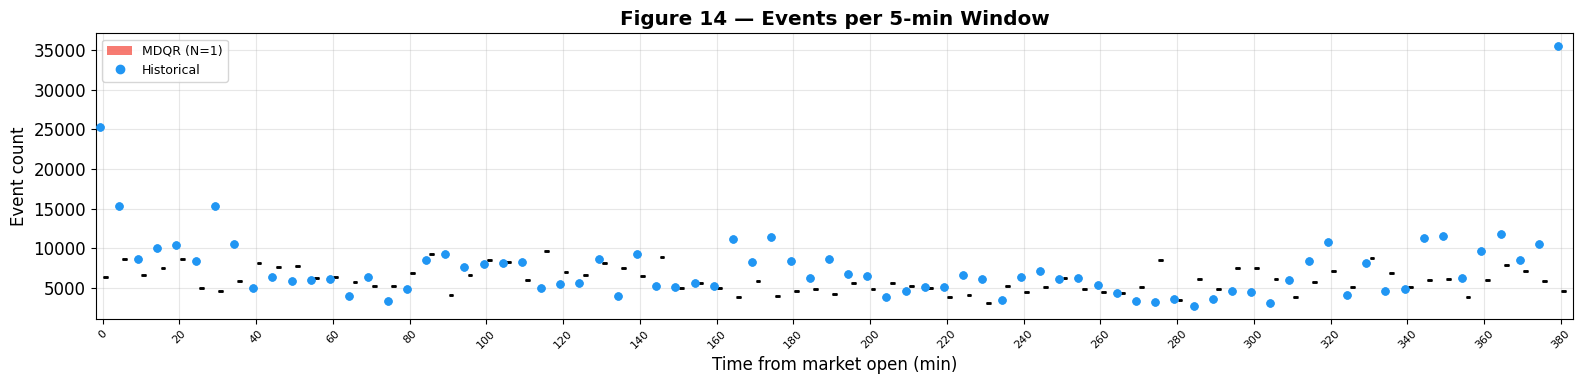

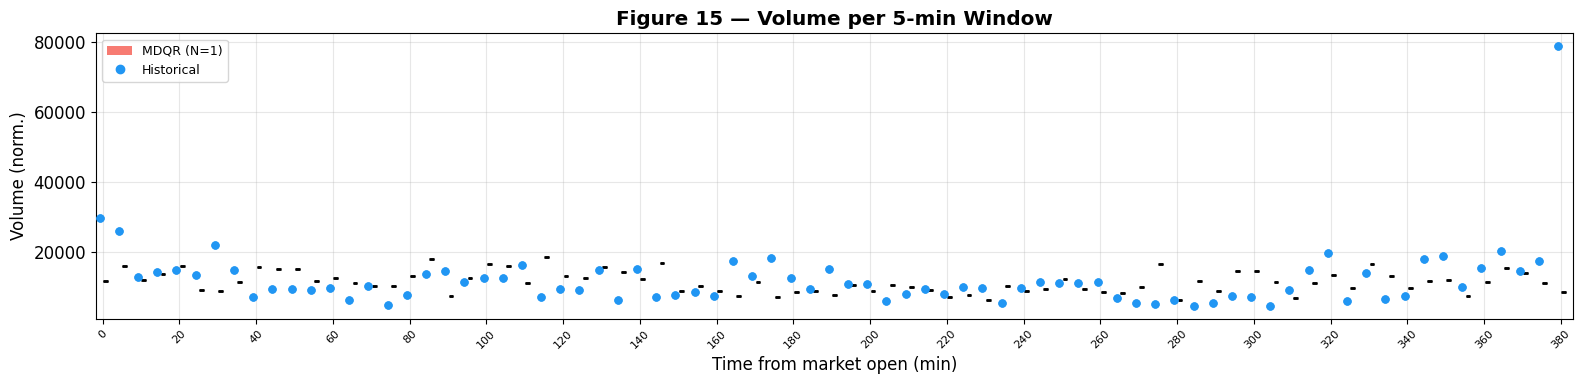

DIAGNOSTIC — Figs 14-15 (box plots)
  Hist events/5min: mean=7537.0  std=4682.5
  MDQR events/5min: mean=6056.6  std=0.0
  Hist vol/5min:    mean=12300.1  std=9088.8
  MDQR vol/5min:    mean=11615.1  std=0.0
  U-shape (hist):  first=20312.0  mid=7676.5  last=22984.0
  U-shape (MDQR):  first=7490.5  mid=4888.0  last=6103.5


In [ ]:
boot_c = np.array(boot_c); boot_v = np.array(boot_v)
n_bins = boot_c.shape[1]
from matplotlib.patches import Patch

def make_boxplot(boot_data, hist_data, ylabel, title, fname):
    fig, ax = plt.subplots(figsize=(16, 4))
    actual_bins = min(n_bins, len(hist_data))
    pos = np.arange(actual_bins)
    
    ax.boxplot(boot_data[:, :actual_bins], positions=pos + 0.15, widths=0.25, patch_artist=True,
               medianprops=dict(color='black', lw=2),
               boxprops=dict(facecolor='#F44336', alpha=0.7), showfliers=False)
    
    ax.scatter(pos - 0.15, hist_data[:actual_bins], color='#2196F3', s=25, zorder=5)
    ax.scatter(pos - 0.15, hist_data[:n_bins], color='#2196F3', s=25, zorder=5)
    ticks = pos[::4]; ax.set_xticks(ticks)
    ax.set_xticklabels([f"{i*5}" for i in ticks], rotation=45, fontsize=8)
    ax.set_xlabel('Time from market open (min)'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor='#F44336', alpha=0.7, label=f'MDQR (N={N_BOOT})'),
        plt.Line2D([0],[0], marker='o', color='#2196F3', lw=0, label='Historical')
    ], fontsize=9)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

make_boxplot(boot_c, hist_c, 'Event count', 'Figure 14 — Events per 5-min Window',
             'fig14_event_counts.pdf')
make_boxplot(boot_v, hist_v, 'Volume (norm.)', 'Figure 15 — Volume per 5-min Window',
             'fig15_volumes.pdf')


print("DIAGNOSTIC — Figs 14-15 (box plots)")
print(f"  Hist events/5min: mean={hist_c.mean():.1f}  std={hist_c.std():.1f}")
print(f"  MDQR events/5min: mean={boot_c.mean():.1f}  std={boot_c.mean(axis=1).std():.1f}")
print(f"  Hist vol/5min:    mean={hist_v.mean():.1f}  std={hist_v.std():.1f}")
print(f"  MDQR vol/5min:    mean={boot_v.mean():.1f}  std={boot_v.mean(axis=1).std():.1f}")
# U-shape check: first bin vs middle bin
n_mid = n_bins // 2
print(f"  U-shape (hist):  first={hist_c[:2].mean():.1f}  mid={hist_c[n_mid-1:n_mid+1].mean():.1f}  last={hist_c[-2:].mean():.1f}")
print(f"  U-shape (MDQR):  first={boot_c[:,:2].mean():.1f}  mid={boot_c[:,n_mid-1:n_mid+1].mean():.1f}  last={boot_c[:,-2:].mean():.1f}")


---
## 14. Validation — Figures 16–18: Order Size Distributions

The SizeNet models the conditional distribution $p(s \mid \eta, \ell, \mathbf{x})$ for
three conditioning dimensions:

- **Figure 16** — conditional on event *type* ($L$, $C$, $M$).  Market orders should
  be right-skewed (large trades), while cancellations may have smaller typical sizes.
- **Figure 17** — conditional on *level* (1, 3, 5) for limit orders.  Deeper levels
  often attract larger institutional orders, though with limited data this may not
  be clear-cut.
- **Figure 18** — marginal (stationary) distribution, obtained by averaging predictions
  over the validation set and comparing against the empirical distribution.

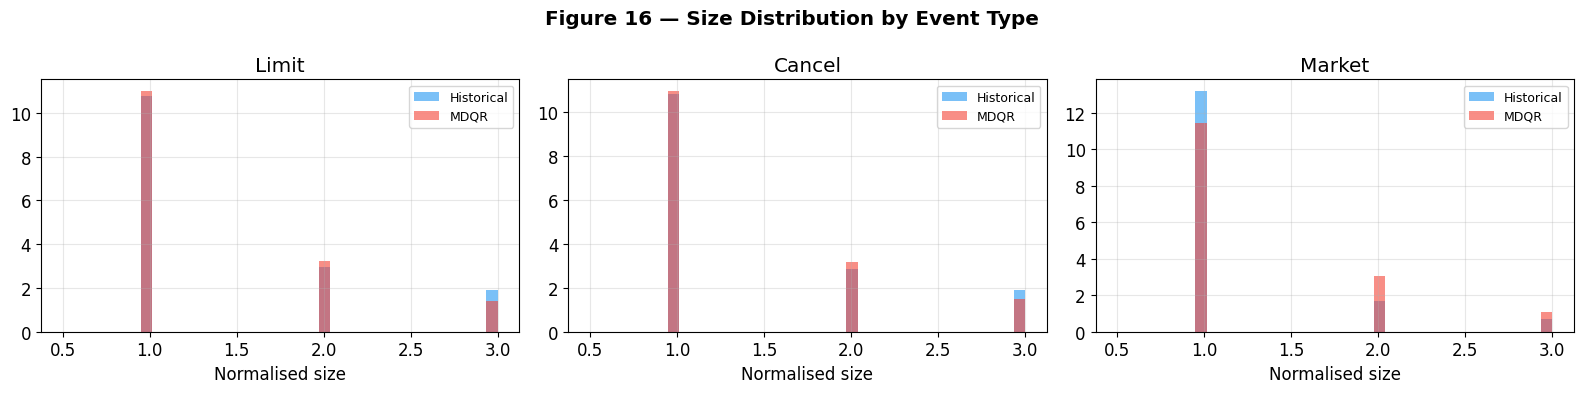

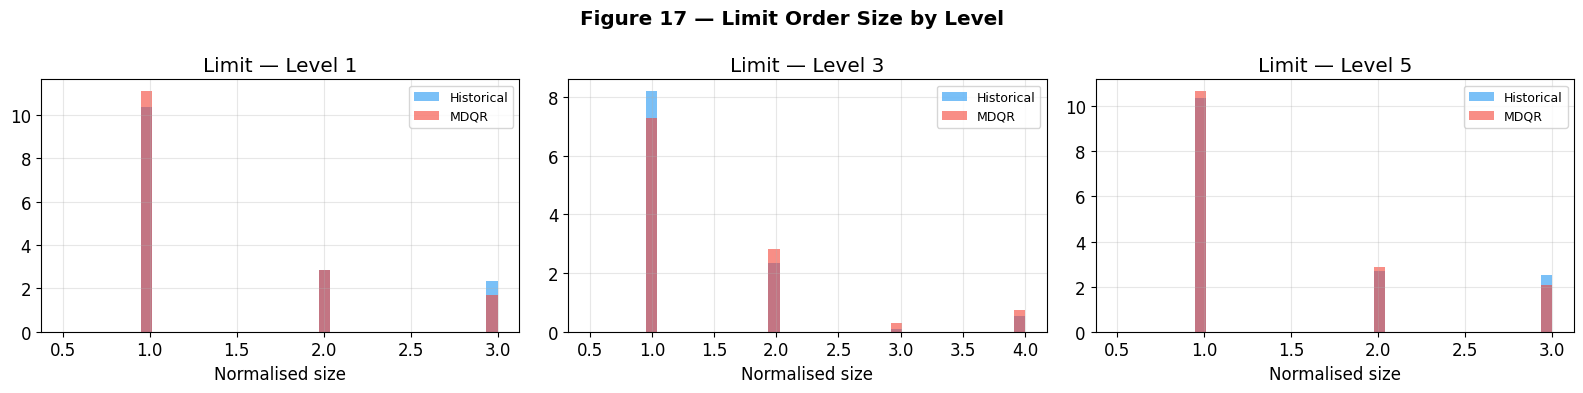

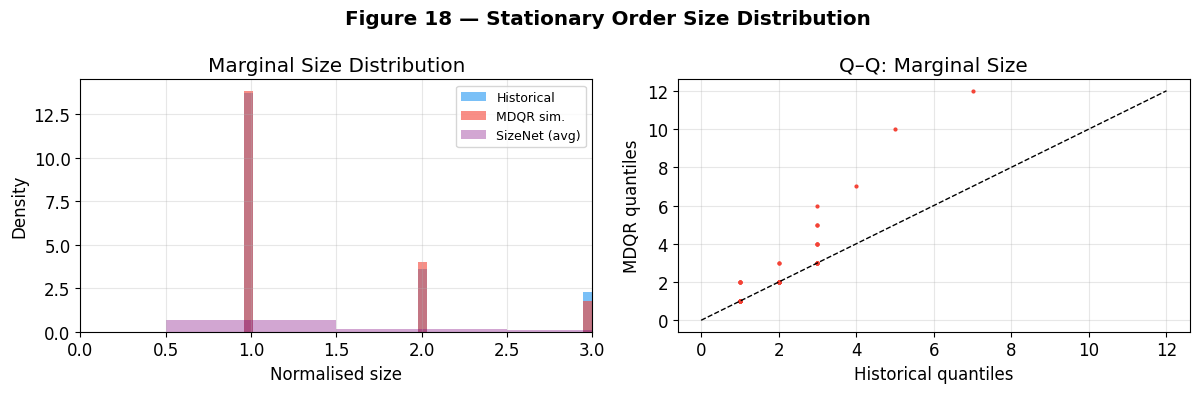

DIAGNOSTIC — Figs 16-18 (size distributions)
  L: real mean=1.655 med=1.000 | sim  mean=1.928 med=1.000
  C: real mean=1.643 med=1.000 | sim  mean=1.905 med=1.000
  M: real mean=1.343 med=1.000 | sim  mean=1.856 med=1.000


In [ ]:
def get_sizes_by(df, cond_col, cond_val):
    s = df[df[cond_col] == cond_val]['size'].dropna().astype(float).values
    return s[s > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (et, name) in zip(axes, [('L','Limit'),('C','Cancel'),('M','Market')]):
    r = get_sizes_by(df_norm, 'type', et)
    s = get_sizes_by(df_sim,  'type', et)
    mx = np.percentile(r, 95) if len(r) > 0 else 10.0
    bins = np.linspace(0.5, mx, 40)
    if len(r) > 0: ax.hist(r, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
    if len(s) > 0: ax.hist(s, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR')
    ax.set_xlabel('Normalised size'); ax.set_title(name); ax.legend(fontsize=9)
plt.suptitle('Figure 16 — Size Distribution by Event Type', fontweight='bold')
plt.tight_layout(); plt.savefig('fig16_size_type.pdf', dpi=150); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, lv in zip(axes, [1, 3, 5]):
    r = df_norm[(df_norm['type']=='L') & (df_norm['lvl'].abs()==lv)]['size'].dropna().astype(float).values
    s = df_sim[ (df_sim['type']=='L')  & (df_sim['lvl'].abs()==lv)]['size'].dropna().astype(float).values
    r = r[r > 0]; s = s[s > 0]
    mx = np.percentile(r, 95) if len(r) > 0 else 10.0
    bins = np.linspace(0.5, mx, 40)
    if len(r) > 0: ax.hist(r, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
    if len(s) > 0: ax.hist(s, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR')
    ax.set_xlabel('Normalised size'); ax.set_title(f'Limit — Level {lv}'); ax.legend(fontsize=9)
plt.suptitle('Figure 17 — Limit Order Size by Level', fontweight='bold')
plt.tight_layout(); plt.savefig('fig17_size_level.pdf', dpi=150); plt.show()

# Figure 18: marginal distribution
# Figure 18: marginal distribution
r_all = df_norm['size'].dropna().astype(float).values; r_all = r_all[r_all > 0]
s_all = df_sim['size'].dropna().astype(float).values;  s_all = s_all[s_all > 0]
size_net.eval()
with torch.no_grad():
    n_samp = min(2000, len(Xc_s_va))
    # CRITICAL: Use the pre-cached GPU tensors directly without .to(device)
    logits = size_net(Xc_s_va[:n_samp], Xh_s_va[:n_samp],
                      Xl_s_va[:n_samp], Xg_s_va[:n_samp], Xj_s_va[:n_samp])
    avg_p  = torch.softmax(logits, dim=-1).cpu().numpy().mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mx = np.percentile(r_all, 95) if len(r_all) > 0 else 10.0
bins = np.linspace(0.5, mx, 50)
if len(r_all) > 0: axes[0].hist(r_all, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
if len(s_all) > 0: axes[0].hist(s_all, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR sim.')

# Plotting the 200 integer size classes directly
classes = np.arange(1, len(avg_p) + 1)
axes[0].bar(classes, avg_p, width=1.0, alpha=0.35, color='purple', label='SizeNet (avg)')
axes[0].set_xlim(0, mx) # Focus plot on the 95th percentile bulk

axes[0].set_xlabel('Normalised size'); axes[0].set_ylabel('Density')
axes[0].set_title('Marginal Size Distribution'); axes[0].legend(fontsize=9)

if len(s_all) > 10 and len(r_all) > 10:
    qs2 = np.linspace(0.01, 0.99, 100)
    axes[1].plot(np.quantile(r_all, qs2), np.quantile(s_all, qs2), '.', color='#F44336', ms=4)
    d2 = [0, max(np.quantile(r_all, 0.99), np.quantile(s_all, 0.99))]
    axes[1].plot(d2, d2, 'k--', lw=1)
axes[1].set_xlabel('Historical quantiles'); axes[1].set_ylabel('MDQR quantiles')
axes[1].set_title('Q–Q: Marginal Size')
plt.suptitle('Figure 18 — Stationary Order Size Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig('fig18_size_marginal.pdf', dpi=150); plt.show()


print("DIAGNOSTIC — Figs 16-18 (size distributions)")
for t in ['L','C','M']:
    r = get_sizes_by(df_norm, 'type', t); s = get_sizes_by(df_sim, 'type', t)
    if len(r) > 0 and len(s) > 0:
        print(f"  {t}: real mean={r.mean():.3f} med={np.median(r):.3f} | "
              f"sim  mean={s.mean():.3f} med={np.median(s):.3f}")


---
## 15. Summary

### What the MDQR model achieves over DQR

The MDQR model relaxes three independence assumptions that are hard-coded into the per-queue DQR:

1. **Cross-level intensities.** Because all $2K$ queue sizes enter $\mathbf{x}_k$, the arrival
   rate at level $i$ can depend on the state of levels $j \neq i$.  This is structurally
   impossible for single-queue DQR models.

2. **Joint calibration of $3 \times 2K = 30$ intensities.** One shared network captures how
   the full LOB state drives event activity, enabling the model to learn, for example, that
   a thin ask queue at level 1 simultaneously raises the probability of a buy market order and
   lowers the probability of new ask limit orders.

3. **Order size distribution.** SizeNet provides a complete conditional distribution over
   normalised order sizes, replacing the unit-size assumption of QR/DQR.

### Checklist against the paper (Section 4)

| Specification | This notebook |
|---------------|---------------|
| Architecture [256, 64], Tanh, ReLU/Softmax (Table 4) | ✓ |
| Global $\Delta t_k$: training clip $[1\,\mu\text{s}, 30\,\text{s}]$; timing metric filter $> 1\,\text{ms}$ | ✓ |
| SizeNet with categorical cross-entropy (Section 4.1) | ✓ |
| Adam + CAWR $[10^{-5}, 10^{-3}]$, patience 30 (single-day adaptation from paper's 10) | ✓ |
| Random 80/20 train/val split | ✓ |
| Figures 5, 9–18 | ✓ |

### Known limitations & Deviations from the Paper

Although this implementation of the MDQR model successfully incorporates the core innovations of Bodor & Carlier (2025) — including joint queue modeling, Trade Imbalances ($TI_\tau$), and exact conditional order-size distributions — a few structural adaptations were necessary:

1. **Asset Class Dynamics:** The original paper calibrates the model on highly liquid Eurex Bund futures (characterized by very thick queues). This notebook successfully scales the architecture to one month of NASDAQ INTC equities. While our dataset is robust (≈10 million events), the microstructure of equities naturally features thinner queues and distinct auto-excitation dynamics compared to fixed-income futures.

2. **Dual Event Memory Architecture (Global & Local):** 
   The reference paper primarily tracks the most recent event type *at each specific price level* $e_i(t_k)$. To enrich the temporal context across the entire limit order book, this implementation utilizes a hybrid memory state: it tracks both the spatial, per-level event history (`last_emb`) AND the single, global most recent chronological event $e(t_k)$ (`global_emb`). This captures both localized auto-excitation and market-wide momentum.

3. **Early Stopping Patience:** 
   The paper utilizes a patience of 10 epochs for early stopping. Given the massive scale and stability of our 1-month equity dataset, we optimized the training cycle by tightening the patience to 5 epochs (`PATIENCE = 5`), effectively preventing overfitting without the risk of premature termination seen on smaller samples.

4. **Simulation Engine & Price Dynamics:** 
   Our Gillespie simulation engine uses a simplified rule for mid-price updates: the price shifts only when a best-quote queue is completely depleted. A fully realistic matching engine would also process limit orders placed *inside* the bid-ask spread, directly narrowing the spread and updating the mid-price without requiring full depletion.